# Proyecto final — Interconnect

## Análisis exploratorio de datos

Interconnect desea predecir la cancelación de clientes para poder ofrecer promociones y planes especiales a quienes presentan riesgo de abandonar la compañía.

El objetivo de este notebook es realizar una exploración completa de los datos antes de entrenar modelos de machine learning.

### Objetivos del análisis

1. Cargar las librerías y los conjuntos de datos.
2. Realizar una revisión preliminar con `head()`, `info()` y `describe()`.
3. Revisar duplicados, valores ausentes, tipos de datos y posibles valores extremos.
4. Realizar ingeniería de características básica.
5. Analizar cada variable de forma univariada y bivariada respecto a la cancelación.
6. Realizar pruebas estadísticas de hipótesis.
7. Extraer conclusiones que orienten la preparación y entrenamiento de los modelos.

> **Nota sobre esta versión del notebook:** este notebook fue adaptado para la estructura del repositorio de portafolio `interconnect-churn-prediction`. Los datos se cargan ahora desde `data/final_provider/` (o `../data/final_provider/` si el notebook se ejecuta desde la carpeta `notebooks/`). El análisis, las decisiones metodológicas, las pruebas estadísticas y el modelo final (LightGBM) no fueron modificados. La versión reproducible y lista para producción de este pipeline se encuentra en `src/data_processing.py`, `src/feature_engineering.py`, `src/train.py` y `src/predict.py`.

## 1. Carga de librerias

In [1]:
# Librerías generales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Estadística
from scipy.stats import (
    chi2_contingency,
    mannwhitneyu,
    randint,
    uniform,
    loguniform
)

# División de datos y ajuste de hiperparámetros
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold
)

# Preprocesamiento
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

# Pipelines
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier
)

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
    roc_curve,
    auc
    
)

# Peso de clases
from sklearn.utils.class_weight import compute_class_weight

## 2. Carga de los datos

Los datos provienen de cuatro fuentes:

- `contract.csv`: información contractual.
- `personal.csv`: información personal.
- `internet.csv`: servicios de Internet.
- `phone.csv`: servicios telefónicos.

La columna `customerID` permite relacionar los cuatro conjuntos de datos.

In [ ]:
import os

data_candidates = [
    'data/final_provider',
    '../data/final_provider',
    'final_provider',
    '/datasets/final_provider'
]

data_dir = next((d for d in data_candidates if os.path.exists(d)), 'final_provider')

contract = pd.read_csv(os.path.join(data_dir, 'contract.csv'))
personal = pd.read_csv(os.path.join(data_dir, 'personal.csv'))
internet = pd.read_csv(os.path.join(data_dir, 'internet.csv'))
phone = pd.read_csv(os.path.join(data_dir, 'phone.csv'))

print(f"Datos cargados exitosamente desde: {data_dir}")


## 3. Exploración preliminar

Primero se inspeccionará cada conjunto de datos por separado para conocer:

- número de registros y columnas;
- tipos de datos
- primeras observaciones
- estadísticas descriptivas
- posibles inconsistencias iniciales

### 3.1 Contract

In [3]:
contract.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


In [4]:
contract.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


In [5]:
contract.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,0612-RTZZA,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BeginDate,7043,77,2014-02-01,366,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EndDate,7043,5,No,5174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,7043,3,Month-to-month,3875,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaperlessBilling,7043,2,Yes,4171,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaymentMethod,7043,4,Electronic check,2365,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MonthlyCharges,7043.0,NaN,NaN,NaN,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75
TotalCharges,7043,6531,,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.2 Personal

In [6]:
personal.head()


,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [7]:
personal.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


In [8]:
personal.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,0612-RTZZA,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3.3 Internet

In [9]:
internet.head()


,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


In [10]:
internet.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


In [11]:
internet.describe(include='all').T


,count,unique,top,freq
customerID,5517,5517,4671-LXRDQ,1
InternetService,5517,2,Fiber optic,3096
OnlineSecurity,5517,2,No,3498
OnlineBackup,5517,2,No,3088
DeviceProtection,5517,2,No,3095
TechSupport,5517,2,No,3473
StreamingTV,5517,2,No,2810
StreamingMovies,5517,2,No,2785


### 3.4 Phone

In [12]:
phone.head()


,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [13]:
phone.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


In [14]:
phone.describe(include='all').T


,count,unique,top,freq
customerID,6361,6361,6621-YOBKI,1
MultipleLines,6361,2,No,3390


### Observaciones preliminares

`contract` y `personal` contienen la información general de todos los clientes, mientras que `internet` y `phone` tienen menos registros.

Esto no debe interpretarse inmediatamente como información ausente. Es probable que los clientes que no aparecen en alguna de estas tablas simplemente no tengan contratado ese servicio.

También se observa que `TotalCharges` está almacenada como variable de tipo texto, aunque conceptualmente corresponde a una variable numérica. Por ello será necesario revisar y convertir esta columna.

Asi mismo las columnas `BeginDate` y `EndDate` estan almacenadas como variable de tipo texto, cuando las mismas corresponden a una variable datetime64, por lo que sera necesario realizar la respectiva conversion de tipo de dato.

# 4. Limpieza e ingeniería de características

### 4.1 Revisión de duplicados

In [15]:
datasets = {
    'contract': contract,
    'personal': personal,
    'internet': internet,
    'phone': phone
}

for name, data in datasets.items():
    print(name)
    print('Filas duplicadas:', data.duplicated().sum())
    print('customerID duplicados:', data['customerID'].duplicated().sum())
    print()

contract
Filas duplicadas: 0
customerID duplicados: 0

personal
Filas duplicadas: 0
customerID duplicados: 0

internet
Filas duplicadas: 0
customerID duplicados: 0

phone
Filas duplicadas: 0
customerID duplicados: 0



### Interpretación

No deberían existir varios registros para un mismo `customerID`, ya que esta variable identifica de forma única a cada cliente.

Si no se encuentran duplicados, no será necesario eliminar observaciones en esta etapa.

### 4.2 Revisión de valores ausentes

In [16]:
for name, data in datasets.items():
    print(f'--- {name.upper()} ---')
    print(data.isna().sum())
    print()

--- CONTRACT ---
customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

--- PERSONAL ---
customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64

--- INTERNET ---
customerID          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64

--- PHONE ---
customerID       0
MultipleLines    0
dtype: int64



Aunque inicialmente pueden no aparecer valores `NaN`, algunas columnas de texto pueden contener cadenas vacías o espacios.

Por esta razón se revisará específicamente `TotalCharges`.

In [17]:
contract[contract['TotalCharges'].astype(str).str.strip() == '']


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
488,4472-LVYGI,2020-02-01,No,Two year,Yes,Bank transfer (automatic),52.55,
753,3115-CZMZD,2020-02-01,No,Two year,No,Mailed check,20.25,
936,5709-LVOEQ,2020-02-01,No,Two year,No,Mailed check,80.85,
1082,4367-NUYAO,2020-02-01,No,Two year,No,Mailed check,25.75,
1340,1371-DWPAZ,2020-02-01,No,Two year,No,Credit card (automatic),56.05,
3331,7644-OMVMY,2020-02-01,No,Two year,No,Mailed check,19.85,
3826,3213-VVOLG,2020-02-01,No,Two year,No,Mailed check,25.35,
4380,2520-SGTTA,2020-02-01,No,Two year,No,Mailed check,20.00,
5218,2923-ARZLG,2020-02-01,No,One year,Yes,Mailed check,19.70,
6670,4075-WKNIU,2020-02-01,No,Two year,No,Mailed check,73.35,


Los registros vacíos de `TotalCharges` corresponden a clientes muy recientes. Dado que la información del dataset es válida al 1 de febrero de 2020, estos clientes todavía no han acumulado cargos totales.

Por lo tanto:

1. se convertirá `TotalCharges` a formato numérico
2. los valores vacíos pasarán temporalmente a `NaN`
3. dichos valores serán sustituidos por `0`

### 4.3 Conversión de fechas

In [18]:
contract['BeginDate'] = pd.to_datetime(contract['BeginDate'])

contract['EndDateDate'] = pd.to_datetime(
    contract['EndDate'],
    errors='coerce'
)

La columna `EndDate` contiene la palabra `No` para los clientes que permanecen activos.

Por esta razón se conserva la columna original y se crea una segunda versión, `EndDateDate`, en la que los clientes activos aparecen como `NaT`.


### 4.4 Conversion de cargos totales

In [19]:
contract['TotalCharges'] = pd.to_numeric(
    contract['TotalCharges'],
    errors='coerce'
)

contract['TotalCharges'] = contract['TotalCharges'].fillna(0)

La columna `TotalCharges` contiene la informacion de tipo numerico como Str, por lo que se realizo el cambio y asimismo se completo los datos ausentes de esta nueva variable con 0.

### 4.5 Creación de la variable objetivo

El objetivo del proyecto consiste en predecir si un cliente cancela.

Se utilizará:

- `0`: el cliente permanece activo.
- `1`: el cliente canceló.

In [20]:
contract['Churn'] = (contract['EndDate'] != 'No').astype(int)

contract['Churn'].value_counts()

0    5174
1    1869
Name: Churn, dtype: int64

In [21]:
contract['Churn'].value_counts(normalize=True).mul(100).round(2)


0    73.46
1    26.54
Name: Churn, dtype: float64

### 4.6 Creación de la antigüedad del cliente

La fecha de inicio por sí sola no representa directamente cuánto tiempo ha permanecido un cliente con la compañía.

Se construirá `TenureMonths`, que representa la duración del contrato en meses.

In [22]:
reference_date = pd.Timestamp('2020-02-01')

end_date = contract['EndDateDate'].fillna(reference_date)

contract['TenureMonths'] = (
    (end_date.dt.year - contract['BeginDate'].dt.year) * 12
    + (end_date.dt.month - contract['BeginDate'].dt.month)
)

contract['TenureMonths'].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: TenureMonths, dtype: float64

Durante el modelado se decidirá si se conserva esta construcción o si se redefine utilizando únicamente información conocida en el instante de predicción.

### 4.7 Unión de los conjuntos de datos

Se utilizará `contract` como tabla principal, ya que contiene todos los clientes.

Las demás tablas se incorporarán mediante un `left join` utilizando `customerID`.

In [23]:
df = (
    contract
    .merge(personal, on='customerID', how='left')
    .merge(internet, on='customerID', how='left')
    .merge(phone, on='customerID', how='left')
)

df.shape

(7043, 23)

In [24]:
df.head()


,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,EndDateDate,Churn,...,Partner,Dependents,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MultipleLines
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85,NaT,0,...,Yes,No,DSL,No,Yes,No,No,No,No,NaN
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.50,NaT,0,...,No,No,DSL,Yes,No,Yes,No,No,No,No
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15,2019-12-01,1,...,No,No,DSL,Yes,Yes,No,No,No,No,No
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75,NaT,0,...,No,No,DSL,Yes,No,Yes,Yes,No,No,NaN
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65,2019-11-01,1,...,No,No,Fiber optic,No,No,No,No,No,No,No


### 4.8 Valores ausentes después de combinar las tablas

In [25]:
df.isna().sum().sort_values(ascending=False)


EndDateDate         5174
StreamingMovies     1526
StreamingTV         1526
TechSupport         1526
DeviceProtection    1526
OnlineBackup        1526
OnlineSecurity      1526
InternetService     1526
MultipleLines        682
SeniorCitizen          0
Dependents             0
Partner                0
customerID             0
BeginDate              0
TenureMonths           0
Churn                  0
TotalCharges           0
MonthlyCharges         0
PaymentMethod          0
PaperlessBilling       0
Type                   0
EndDate                0
gender                 0
dtype: int64

Los valores ausentes generados al unir `internet` y `phone` no deben eliminarse automáticamente.

Un cliente que no aparece en `internet.csv` probablemente no tiene servicio de Internet y un cliente que no aparece en `phone.csv` probablemente no tiene servicio telefónico.

Por ello se convertirán estos valores en categorías explícitas.

In [26]:
internet_columns = [
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

df[internet_columns] = df[internet_columns].fillna('No internet service')

df['MultipleLines'] = df['MultipleLines'].fillna('No phone service')

In [27]:
df.isna().sum().sort_values(ascending=False)


EndDateDate         5174
customerID             0
SeniorCitizen          0
StreamingMovies        0
StreamingTV            0
TechSupport            0
DeviceProtection       0
OnlineBackup           0
OnlineSecurity         0
InternetService        0
Dependents             0
Partner                0
gender                 0
BeginDate              0
TenureMonths           0
Churn                  0
TotalCharges           0
MonthlyCharges         0
PaymentMethod          0
PaperlessBilling       0
Type                   0
EndDate                0
MultipleLines          0
dtype: int64

### 4.9 Creación de nuevas características

Se crearán algunas variables sencillas que resumen la relación del cliente con los servicios de Interconnect.

### `NumServices`

Cuenta cuántos servicios adicionales tiene contratados el cliente.

### `HasInternet`

Indica si el cliente posee algún servicio de Internet.

### `HasPhone`

Indica si el cliente posee servicio telefónico.

In [28]:
service_columns = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'MultipleLines'
]

df['NumServices'] = sum(
    (df[column] == 'Yes').astype(int)
    for column in service_columns
)

df['HasInternet'] = (
    df['InternetService'] != 'No internet service'
).astype(int)

df['HasPhone'] = (
    df['MultipleLines'] != 'No phone service'
).astype(int)

In [29]:
df[['NumServices', 'HasInternet', 'HasPhone']].head()


,NumServices,HasInternet,HasPhone
0,1,1,0
1,2,1,1
2,2,1,1
3,3,1,0
4,0,1,1


### 4.10 Revisión de valores extremos

Se utilizará el criterio del rango intercuartílico (IQR) para detectar posibles observaciones extremas en las variables numéricas principales.

In [30]:
numeric_columns = [
    'MonthlyCharges',
    'TotalCharges',
    'TenureMonths',
    'NumServices'
]

for column in numeric_columns:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    print(column)
    print('Límite inferior:', lower)
    print('Límite superior:', upper)
    print('Valores extremos:', len(outliers))
    print()

MonthlyCharges
Límite inferior: -46.02499999999999
Límite superior: 171.375
Valores extremos: 0

TotalCharges
Límite inferior: -4683.525
Límite superior: 8868.675
Valores extremos: 0

TenureMonths
Límite inferior: -60.0
Límite superior: 124.0
Valores extremos: 0

NumServices
Límite inferior: -3.5
Límite superior: 8.5
Valores extremos: 0



### Decisión sobre valores extremos

Los posibles valores extremos no se eliminarán automáticamente.

Antes de eliminar observaciones es necesario determinar si representan errores o simplemente clientes con comportamientos poco frecuentes pero válidos.

En un problema de cancelación, estos clientes pueden contener precisamente información útil para detectar comportamientos de riesgo.

# 5. Análisis univariado

El análisis univariado permite estudiar la distribución de cada característica de forma independiente.

### 5.1 Variables numéricas

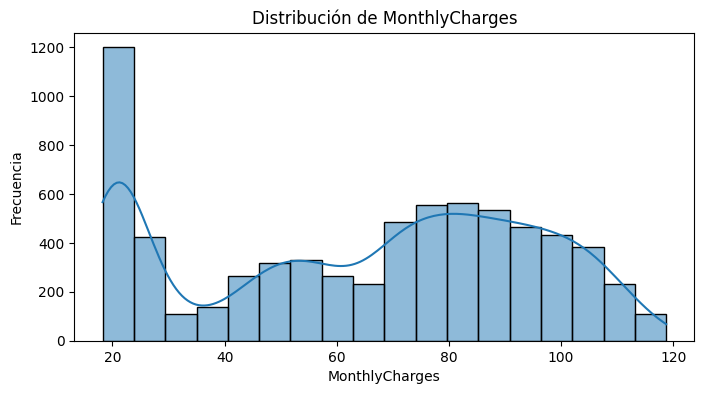

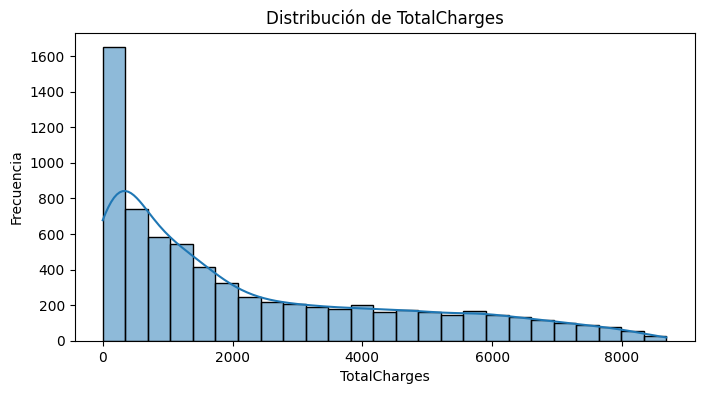

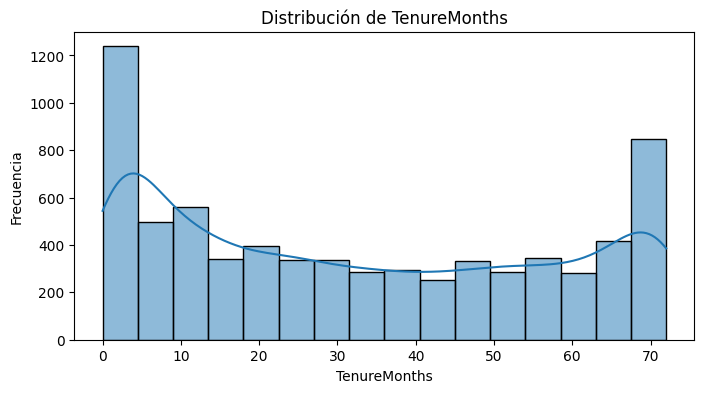

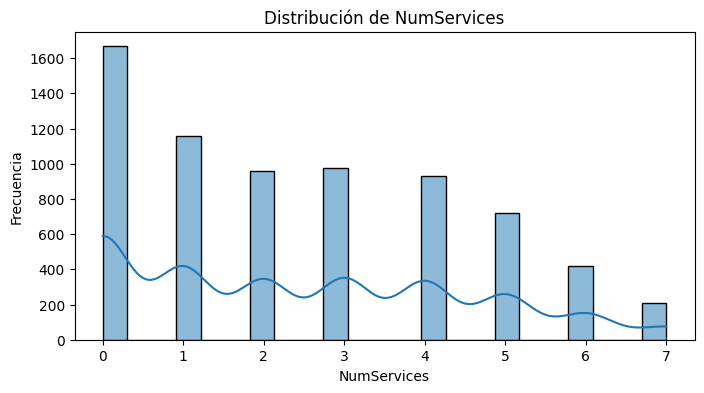

In [31]:
for column in numeric_columns:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df,
        x=column,
        kde=True
    )

    plt.title(f'Distribución de {column}')
    plt.xlabel(column)
    plt.ylabel('Frecuencia')
    plt.show()

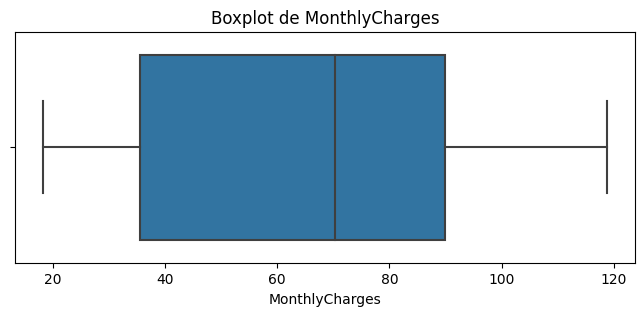

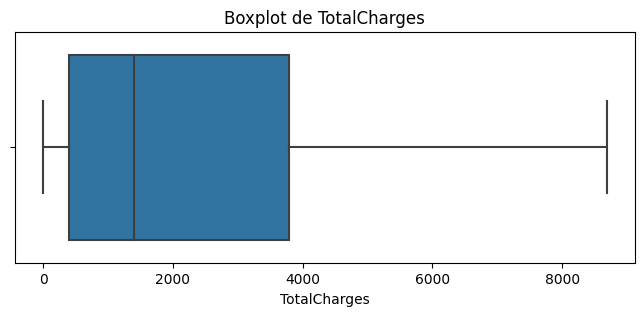

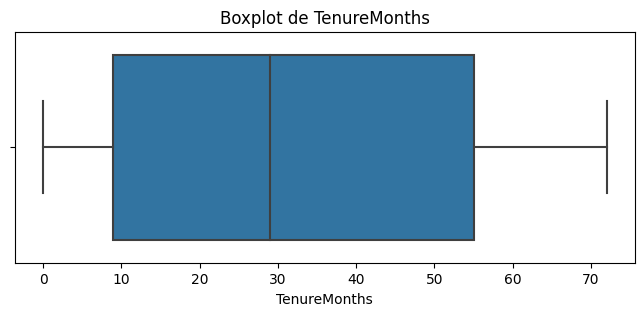

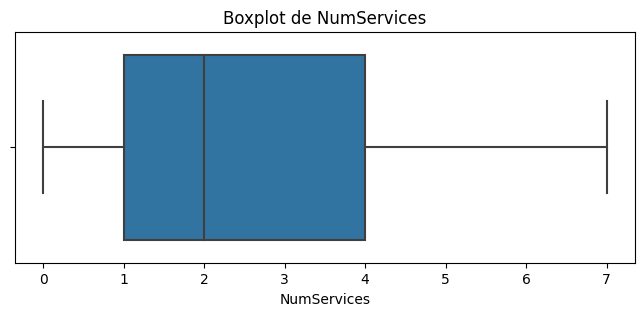

In [32]:
for column in numeric_columns:
    plt.figure(figsize=(8, 3))

    sns.boxplot(
        data=df,
        x=column
    )

    plt.title(f'Boxplot de {column}')
    plt.show()

### Interpretación

Los histogramas permiten evaluar:

- concentración de los valores
- asimetría
- presencia de distintos grupos
- posibles colas largas

Los boxplots permiten complementar esta revisión observando mediana, rango intercuartílico y posibles valores extremos.

### 5.2 Variables categóricas

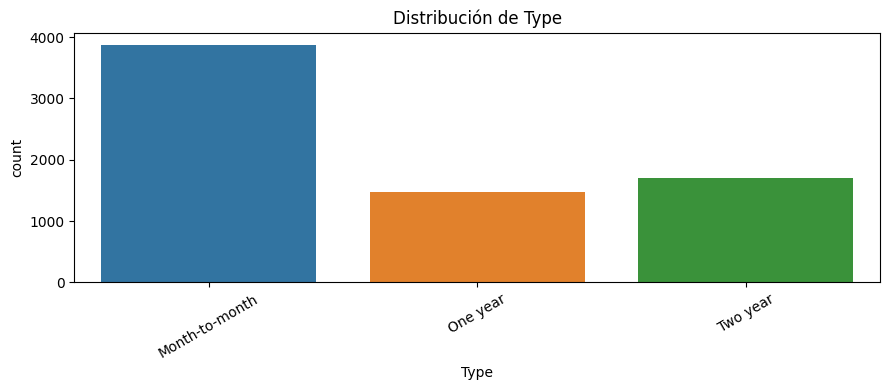

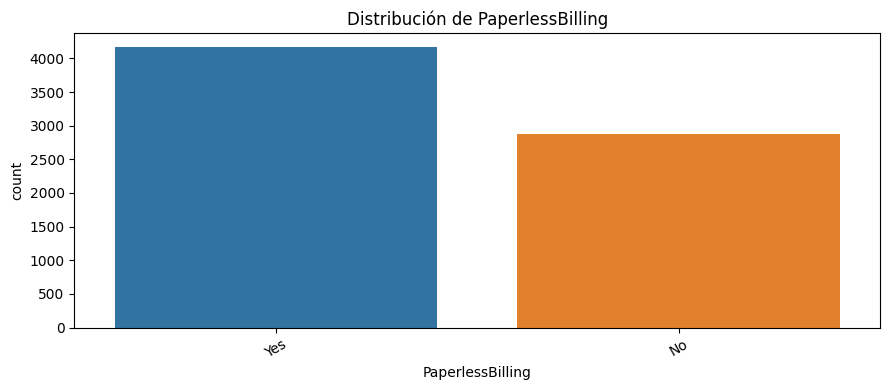

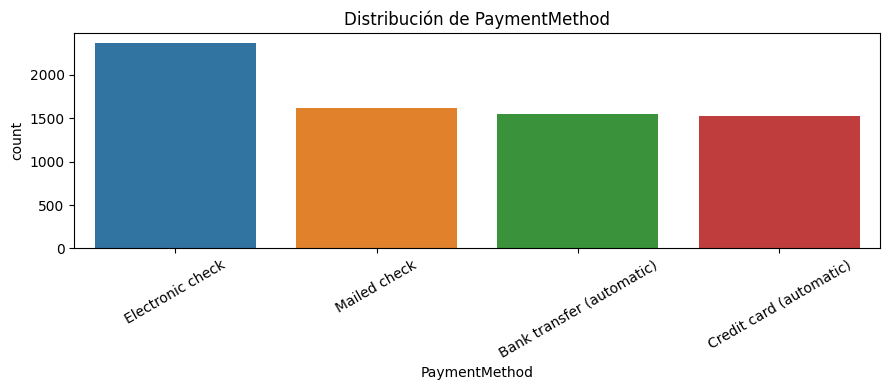

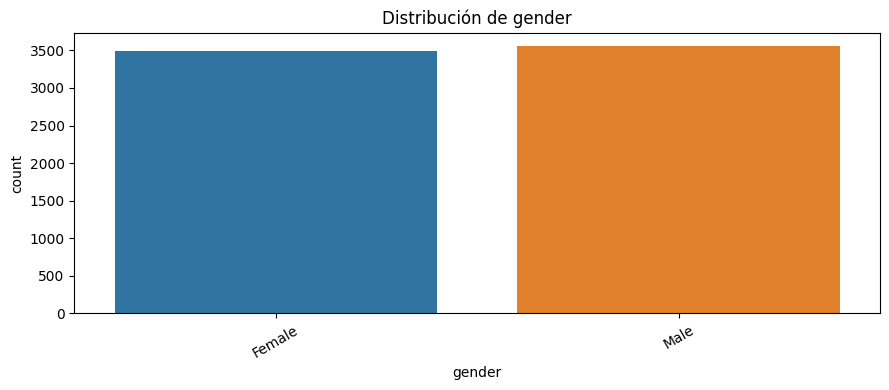

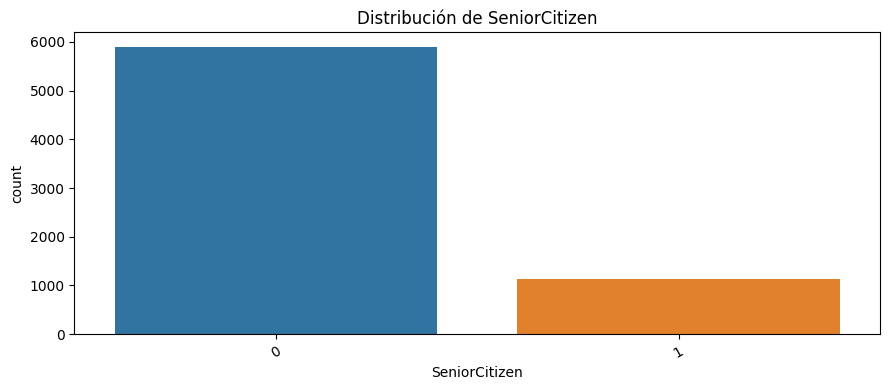

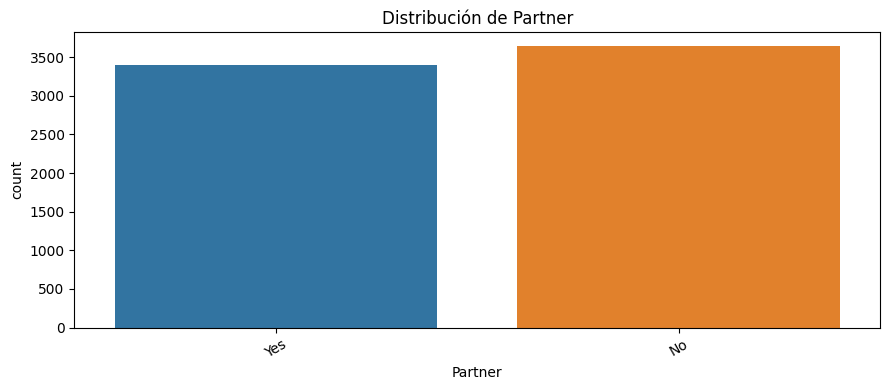

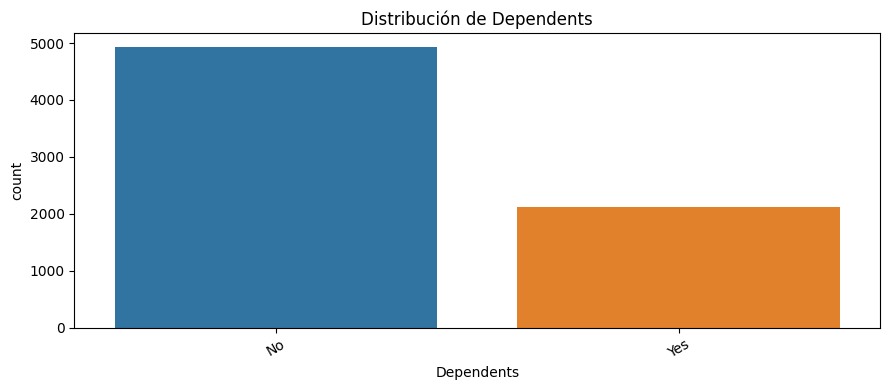

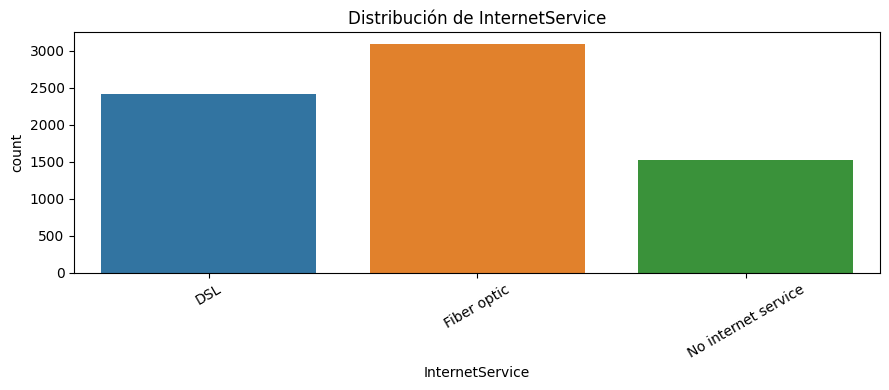

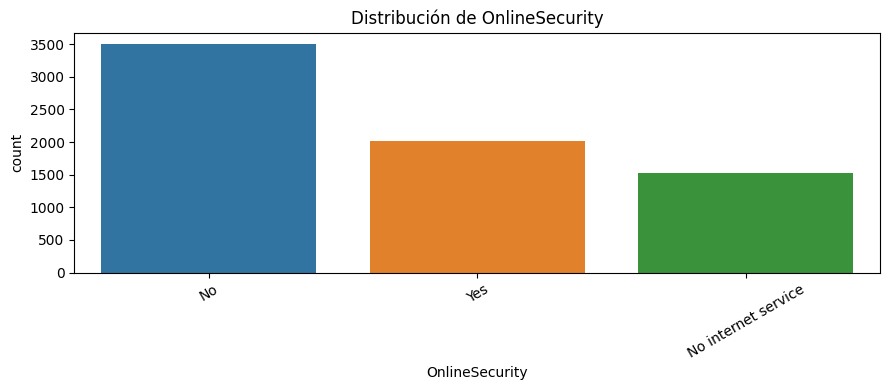

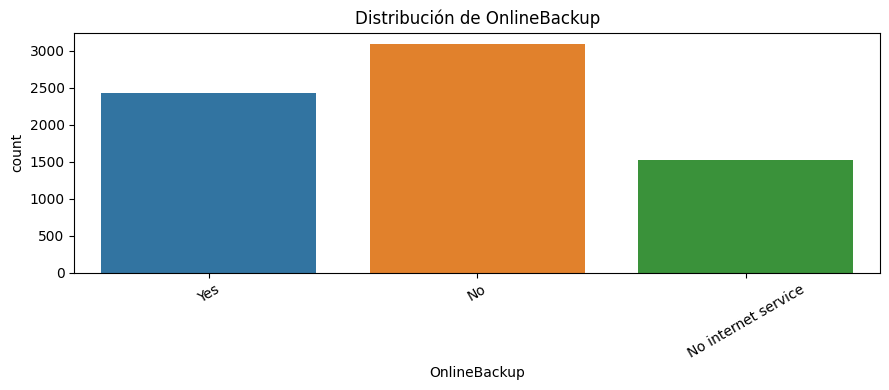

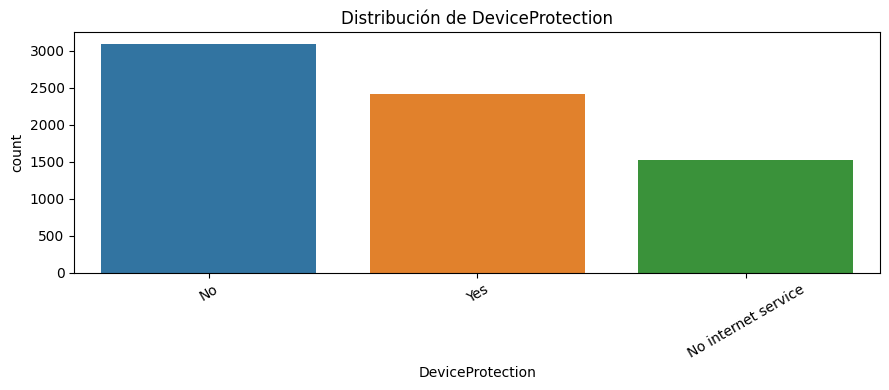

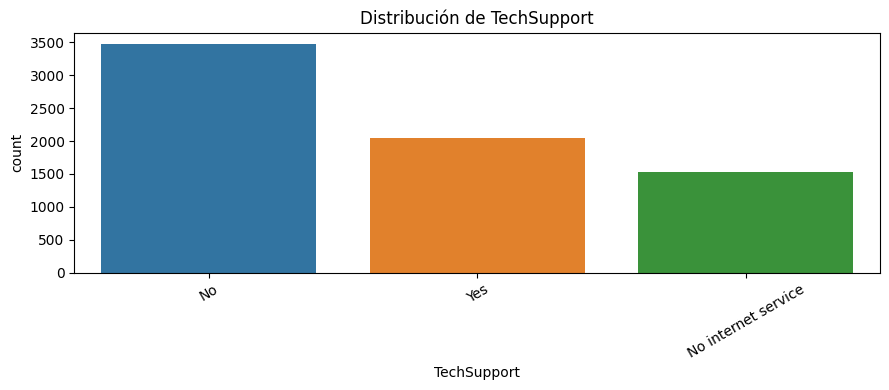

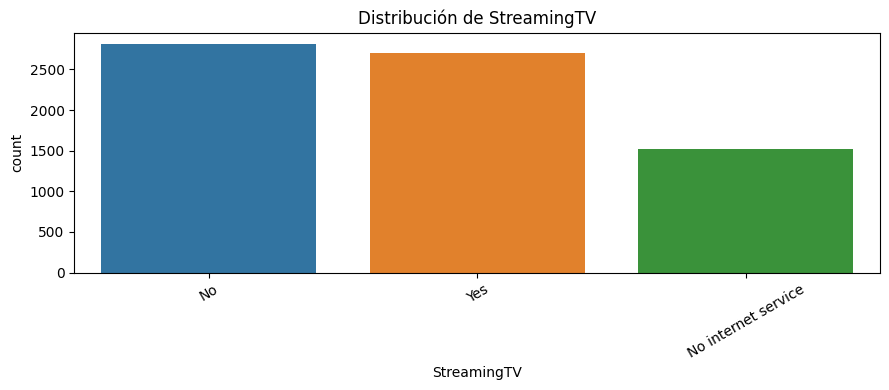

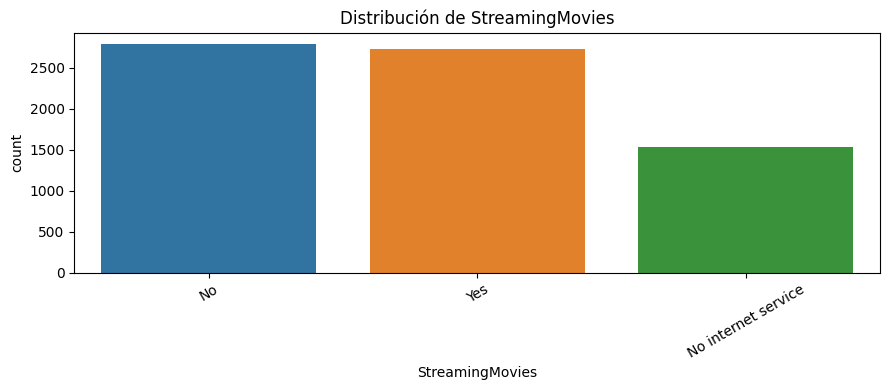

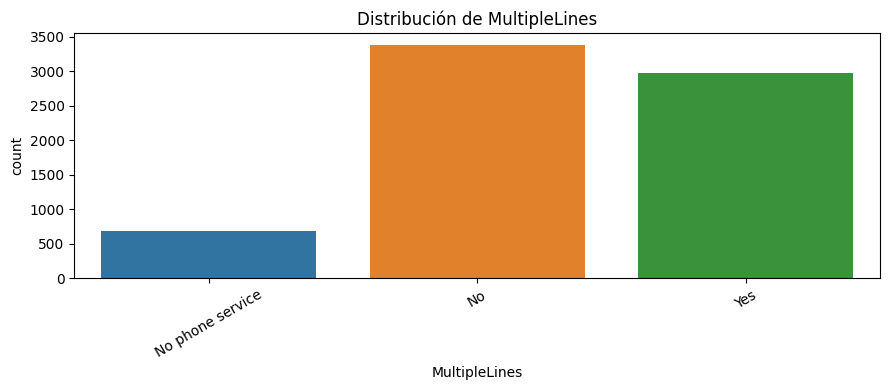

In [33]:
categorical_columns = [
    'Type',
    'PaperlessBilling',
    'PaymentMethod',
    'gender',
    'SeniorCitizen',
    'Partner',
    'Dependents',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'MultipleLines'
]

for column in categorical_columns:
    plt.figure(figsize=(9, 4))

    sns.countplot(
        data=df,
        x=column
    )

    plt.title(f'Distribución de {column}')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### Interpretación

Las gráficas de barras permiten identificar qué categorías son más frecuentes y detectar posibles categorías con muy pocos registros.

Esta revisión también será útil para decidir posteriormente cómo codificar las variables categóricas.

# 6. Análisis bivariado

El objetivo principal del análisis bivariado será comparar cada característica con la variable objetivo `Churn`.

### 6.1 Variables numéricas frente a Churn

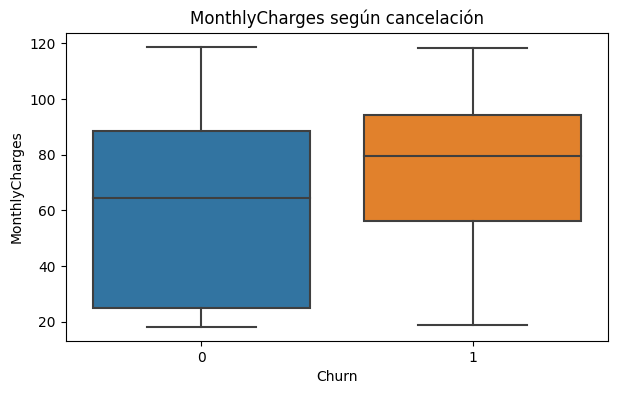

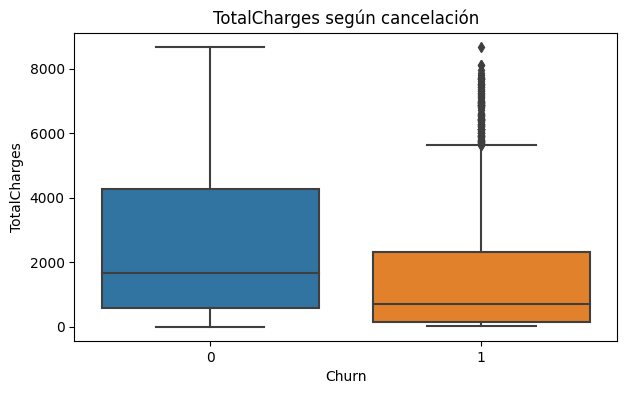

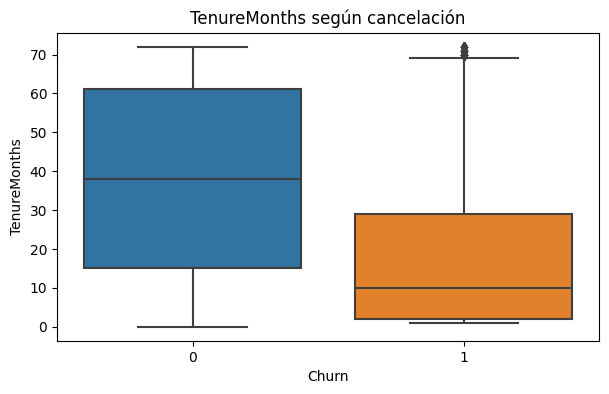

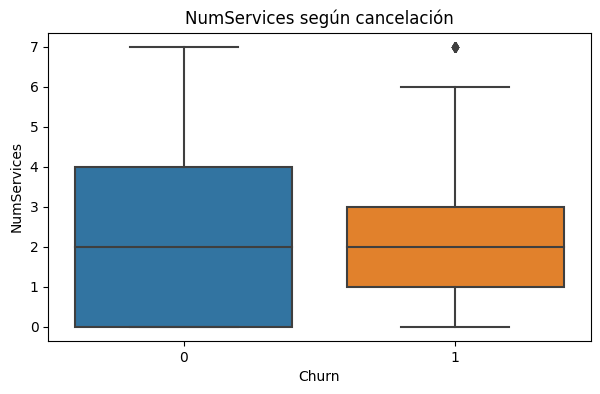

In [34]:
for column in numeric_columns:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x='Churn',
        y=column
    )

    plt.title(f'{column} según cancelación')
    plt.xlabel('Churn')
    plt.ylabel(column)
    plt.show()

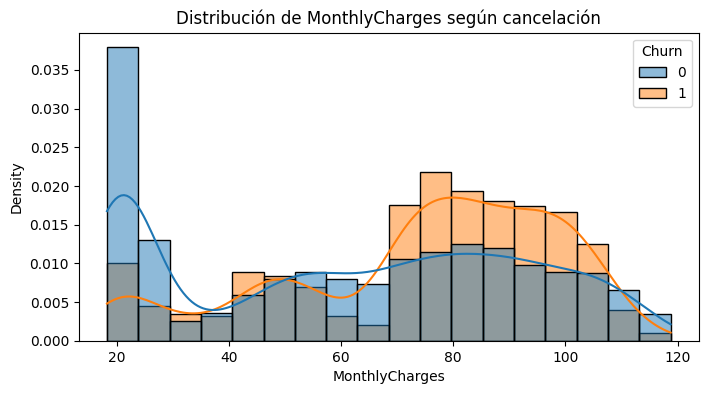

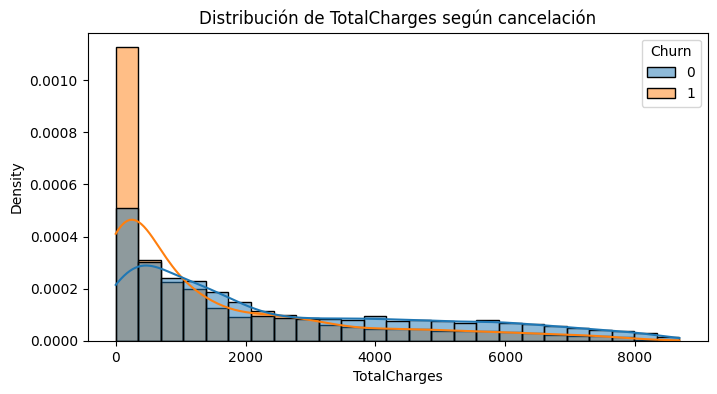

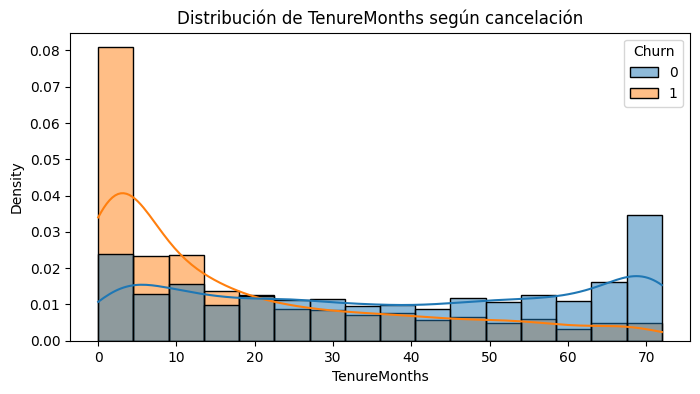

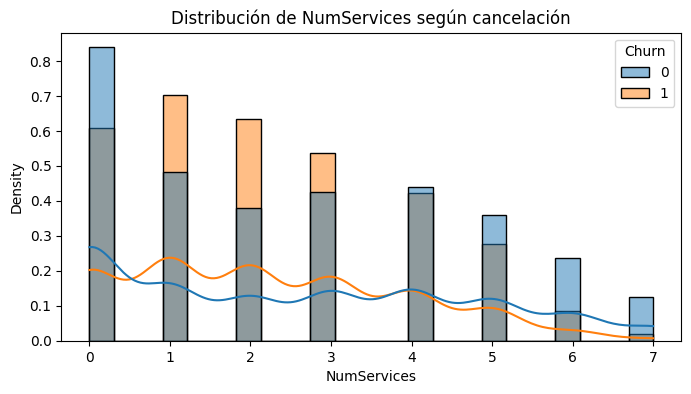

In [35]:
for column in numeric_columns:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df,
        x=column,
        hue='Churn',
        kde=True,
        stat='density',
        common_norm=False
    )

    plt.title(f'Distribución de {column} según cancelación')
    plt.show()

### Resumen estadístico por clase

In [36]:
df.groupby('Churn')[numeric_columns].agg([
    'count',
    'mean',
    'median',
    'std'
]).round(2)

MonthlyCharges                      TotalCharges                    \
               count   mean median    std        count     mean   median   
Churn                                                                      
0               5174  61.27  64.43  31.09         5174  2549.91  1679.52   
1               1869  74.44  79.65  24.67         1869  1531.80   703.55   

               TenureMonths                      NumServices               \
           std        count   mean median    std       count  mean median   
Churn                                                                       
0      2329.95         5174  37.57     38  24.11        5174  2.55      2   
1      1890.82         1869  17.98     10  19.53        1869  2.22      2   

             
        std  
Churn        
0      2.15  
1      1.70

### Interpretación

La comparación entre ambos grupos permite observar si los clientes que cancelan tienen características numéricas diferentes a quienes permanecen.

Se prestará especial atención a:

- cargos mensuales
- cargos acumulados
- antigüedad
- cantidad de servicios contratados

## 6.2 Variables categóricas frente a Churn

Para cada variable categórica se calculará la proporción de cancelación dentro de cada categoría.

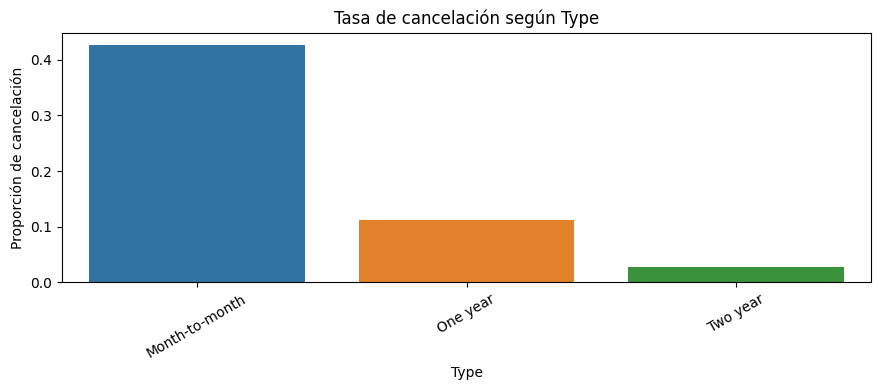

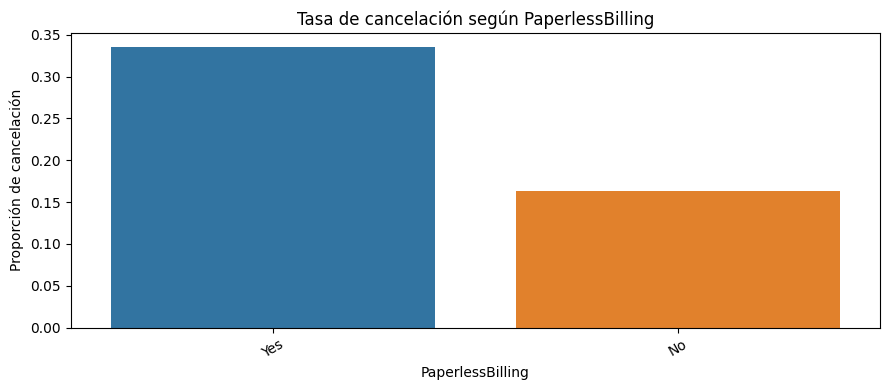

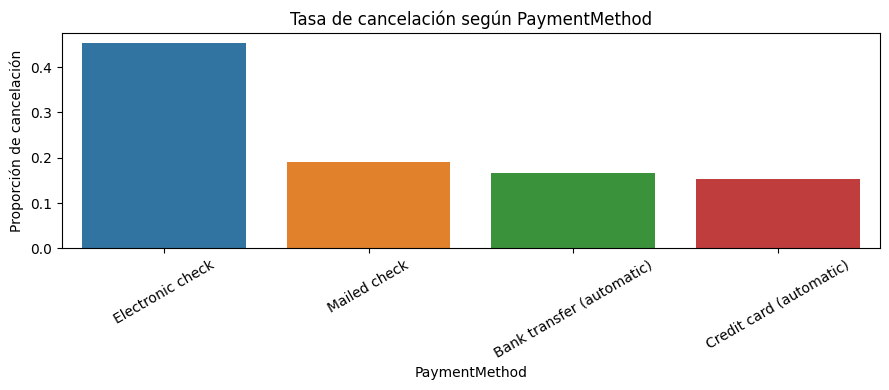

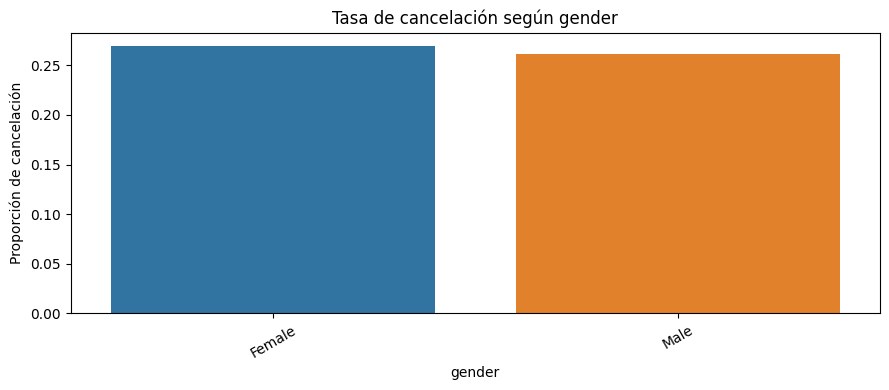

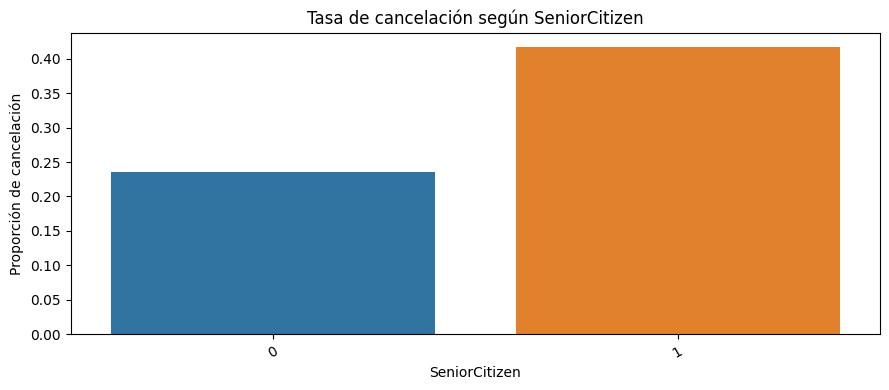

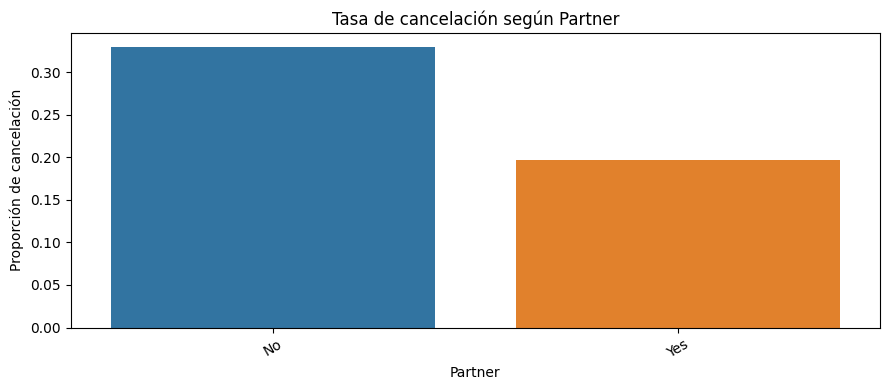

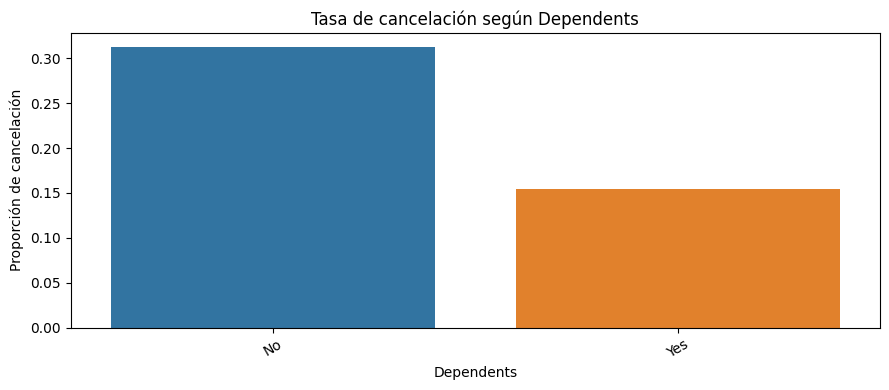

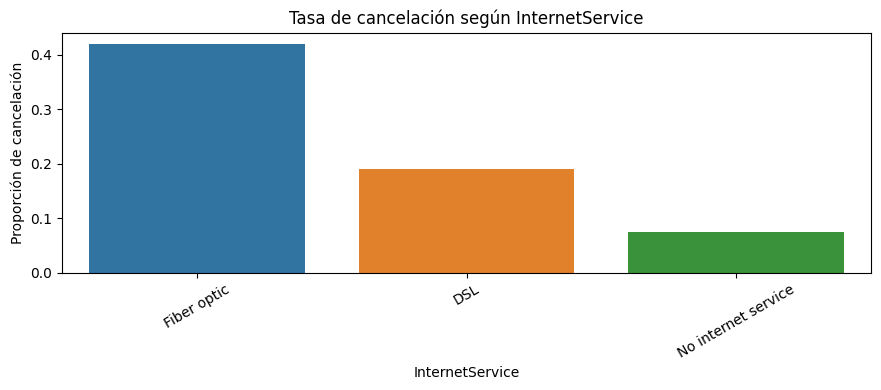

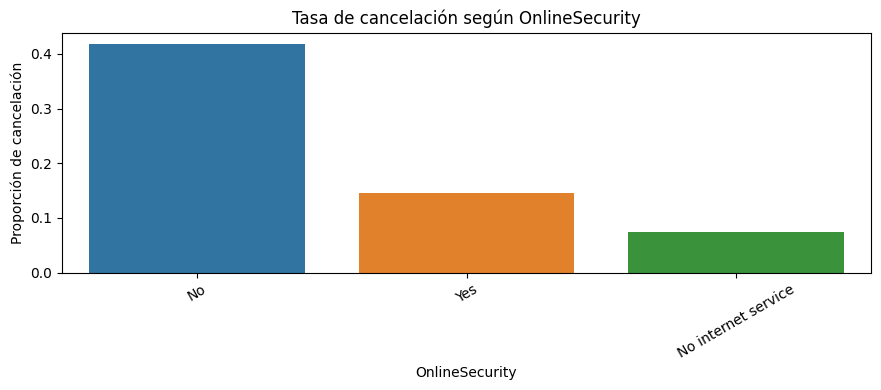

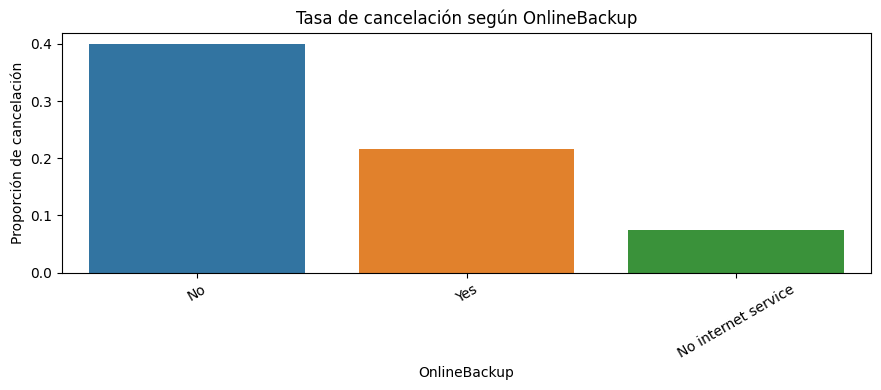

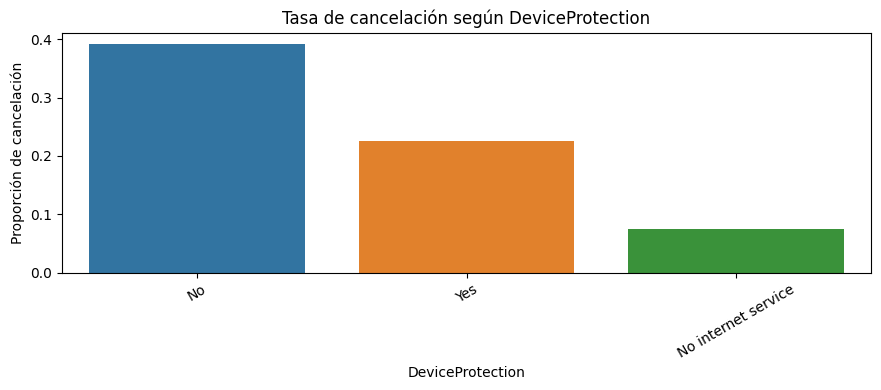

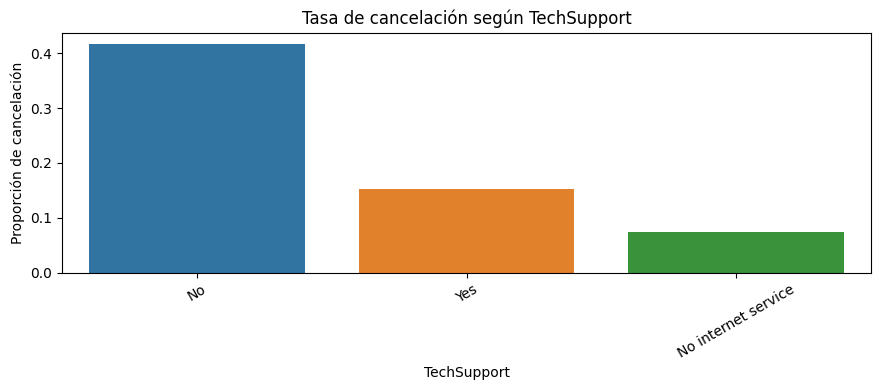

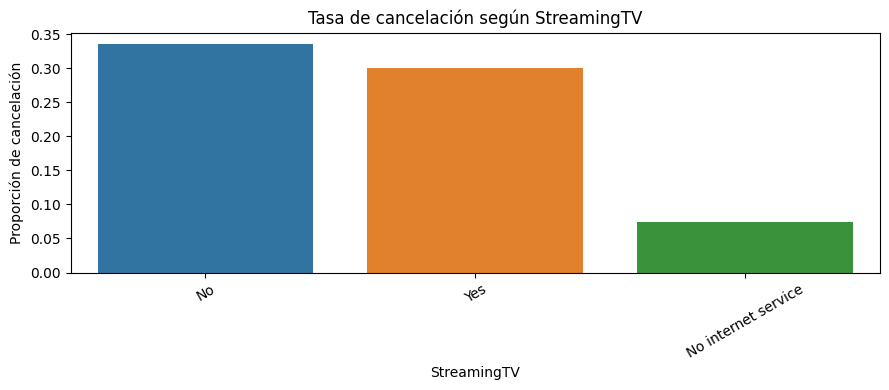

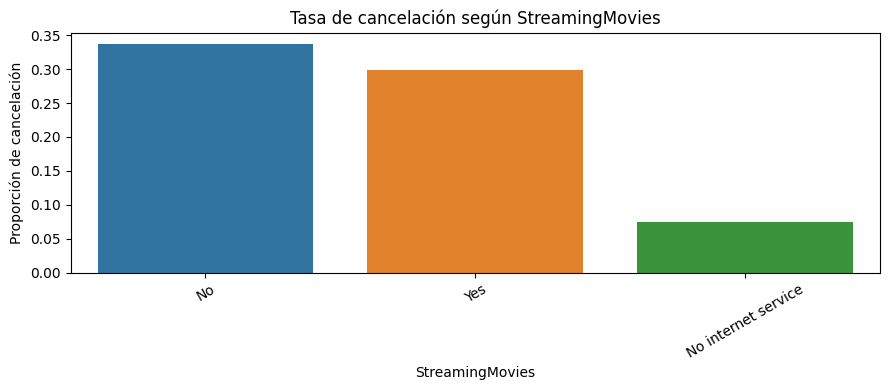

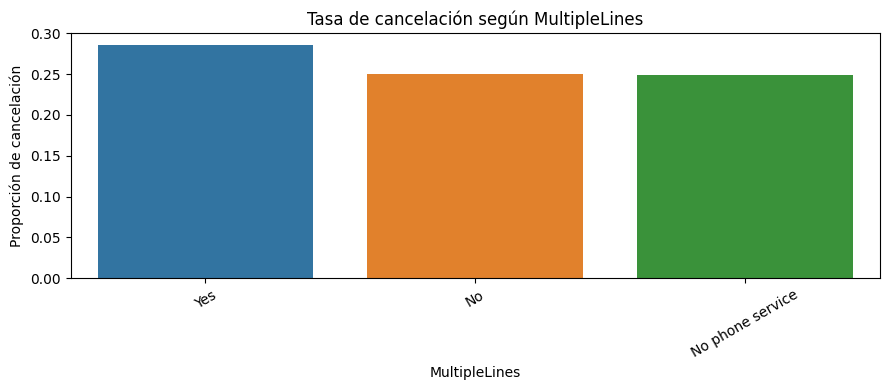

In [37]:
for column in categorical_columns:

    churn_rate = (
        df.groupby(column)['Churn']
        .mean()
        .sort_values(ascending=False)
        .reset_index()
    )

    plt.figure(figsize=(9, 4))

    sns.barplot(
        data=churn_rate,
        x=column,
        y='Churn'
    )

    plt.title(f'Tasa de cancelación según {column}')
    plt.ylabel('Proporción de cancelación')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### Tablas de tasa de cancelación

Estas tablas permiten ver los valores exactos observados en las gráficas anteriores.

In [38]:
for column in categorical_columns:
    print(f'--- {column} ---')

    display(
        df.groupby(column)['Churn']
        .agg(['count', 'mean'])
        .rename(columns={'mean': 'churn_rate'})
        .sort_values('churn_rate', ascending=False)
    )

    print()

--- Type ---


,count,churn_rate
Type,,
Month-to-month,3875,0.427097
One year,1473,0.112695
Two year,1695,0.028319



--- PaperlessBilling ---


,count,churn_rate
PaperlessBilling,,
Yes,4171,0.335651
No,2872,0.163301



--- PaymentMethod ---


...

,count,churn_rate
StreamingTV,,
No,2810,0.335231
Yes,2707,0.300702
No internet service,1526,0.074050



--- StreamingMovies ---


,count,churn_rate
StreamingMovies,,
No,2785,0.336804
Yes,2732,0.299414
No internet service,1526,0.074050



--- MultipleLines ---


,count,churn_rate
MultipleLines,,
Yes,2971,0.286099
No,3390,0.250442
No phone service,682,0.249267


# 7. Pruebas de hipótesis

Las gráficas permiten detectar diferencias visuales, pero se utilizarán pruebas estadísticas para comprobar si dichas diferencias tienen evidencia estadística.

## 7.1 Variables numéricas — prueba de Mann-Whitney U

Para comparar las variables numéricas entre clientes que cancelaron y clientes que permanecieron se utilizará la prueba de Mann-Whitney U.

### Hipótesis

**H₀:** la distribución de la variable es igual entre los clientes que cancelaron y quienes permanecieron.

**H₁:** la distribución de la variable es diferente entre ambos grupos.

Se utilizará:

alpha = 0.05

In [39]:
alpha = 0.05

mann_results = []

for column in numeric_columns:

    active = df[df['Churn'] == 0][column]
    churned = df[df['Churn'] == 1][column]

    statistic, p_value = mannwhitneyu(
        active,
        churned,
        alternative='two-sided'
    )

    mann_results.append({
        'Variable': column,
        'Statistic': statistic,
        'p_value': p_value,
        'Decision': 'Rechazar H0' if p_value < alpha else 'No rechazar H0'
    })

mann_results = pd.DataFrame(mann_results)
mann_results

,Variable,Statistic,p_value,Decision
0,MonthlyCharges,3667080.5,3.311628e-54,Rechazar H0
1,TotalCharges,6288982.0,5.685034e-83,Rechazar H0
2,TenureMonths,7154668.0,2.419636e-208,Rechazar H0
3,NumServices,5126960.0,8.630194e-05,Rechazar H0


### Interpretación



Con un nivel de confianza del 95%`, con un pvalor <0.0001, se rechaza la hipótesis nula y se considera que existe evidencia estadística de diferencias entre los clientes que cancelaron y los que permanecieron.

La significancia estadística no implica necesariamente que una característica sea suficiente por sí sola para predecir la cancelación, por lo que deberá evaluarse en conjunto con las demás variables dentro de los modelos.

## 7.2 Variables categóricas — prueba Chi-cuadrado

Para analizar la relación entre las variables categóricas y `Churn` se utilizará la prueba Chi-cuadrado de independencia.

### Hipótesis

**H₀:** la variable categórica y la cancelación son independientes.

**H₁:** existe asociación entre la variable categórica y la cancelación.

In [40]:
chi_results = []

for column in categorical_columns:

    table = pd.crosstab(df[column], df['Churn'])

    chi2, p_value, dof, expected = chi2_contingency(table)

    chi_results.append({
        'Variable': column,
        'Chi2': chi2,
        'p_value': p_value,
        'Decision': 'Rechazar H0' if p_value < alpha else 'No rechazar H0'
    })

chi_results = pd.DataFrame(chi_results)
chi_results.sort_values('p_value')

,Variable,Chi2,p_value,Decision
0,Type,1184.596572,5.863038e-258,Rechazar H0
8,OnlineSecurity,849.998968,2.661150e-185,Rechazar H0
11,TechSupport,828.197068,1.443084e-180,Rechazar H0
7,InternetService,732.309590,9.571788e-160,Rechazar H0
2,PaymentMethod,648.142327,3.682355e-140,Rechazar H0
9,OnlineBackup,601.812790,2.079759e-131,Rechazar H0
10,DeviceProtection,558.419369,5.505219e-122,Rechazar H0
13,StreamingMovies,375.661479,2.667757e-82,Rechazar H0
12,StreamingTV,374.203943,5.528994e-82,Rechazar H0
1,PaperlessBilling,258.277649,4.073355e-58,Rechazar H0


### Interpretación

Con un nivel de confianza del 95 % y un nivel de significancia de 0.05, se rechaza la hipótesis nula para todas las variables categóricas analizadas excepto `gender`.

Por lo tanto, existe evidencia estadística de asociación entre la cancelación del cliente y variables como el tipo de contrato, método de pago, servicio de Internet, seguridad en línea, soporte técnico y las demás características significativas.

En el caso de `gender`, el p-value es mayor que 0.05, por lo que no se rechaza la hipótesis nula y no se encuentra evidencia estadística suficiente de asociación con la cancelación.

## 7.3 V de Cramér

El valor `p` permite determinar si existe una asociación estadísticamente significativa, pero no indica directamente qué tan fuerte es dicha asociación.

Para complementar la prueba Chi-cuadrado se calculará la V de Cramér.

In [41]:
def cramers_v(x, y):

    table = pd.crosstab(x, y)

    chi2 = chi2_contingency(table)[0]
    n = table.sum().sum()

    phi2 = chi2 / n

    r, k = table.shape

    return np.sqrt(phi2 / min(k - 1, r - 1))

In [42]:
cramer_results = []

for column in categorical_columns:

    cramer_results.append({
        'Variable': column,
        'Cramers_V': cramers_v(df[column], df['Churn'])
    })

cramer_results = pd.DataFrame(cramer_results)

cramer_results.sort_values(
    'Cramers_V',
    ascending=False
).round(3)

,Variable,Cramers_V
0,Type,0.410
8,OnlineSecurity,0.347
11,TechSupport,0.343
7,InternetService,0.322
2,PaymentMethod,0.303
9,OnlineBackup,0.292
10,DeviceProtection,0.282
13,StreamingMovies,0.231
12,StreamingTV,0.231
1,PaperlessBilling,0.191


### Interpretación de V de Cramér

La V de Cramér complementa los resultados obtenidos mediante la prueba Chi-cuadrado al permitir evaluar la intensidad de la asociación entre cada variable categórica y la cancelación.

La variable `Type` presenta la asociación más fuerte con `Churn`, con una V de Cramér de 0.410.

También destacan `OnlineSecurity`, `TechSupport`, `InternetService` y `PaymentMethod`, con asociaciones mayores que las observadas en el resto de las características.

Por otro lado, `MultipleLines` presenta una asociación muy débil, a pesar de haber resultado estadísticamente significativa en la prueba Chi-cuadrado.

Finalmente, `gender` presenta una V de Cramér de 0.008, indicando una asociación prácticamente inexistente con la cancelación, lo cual es consistente con el resultado no significativo obtenido en la prueba Chi-cuadrado.

# 8. Conclusiones del análisis exploratorio

El análisis exploratorio permite identificar varios patrones que pueden ser útiles para predecir la cancelación.

En primer lugar, el conjunto de datos presenta un desbalance moderado entre clientes activos y clientes que cancelaron, por lo que durante el modelado será conveniente realizar una división estratificada de los datos.

No se encontraron razones para eliminar masivamente observaciones. Los valores ausentes encontrados después de combinar las tablas representan principalmente ausencia de determinados servicios, por lo que fueron convertidos en categorías explícitas. Los valores vacíos de `TotalCharges` corresponden a clientes recientes y fueron sustituidos por cero.

El análisis bivariado permitió  identificar qué características presentan diferencias relevantes entre clientes que cancelan y clientes que permanecen. Variables como tipo de contrato, método de pago, servicio de Internet, seguridad en línea, soporte técnico, cargos mensuales y duración de la relación con el cliente son especialmente importantes para revisar.

Las pruebas de Mann-Whitney U permiten comprobar si las variables numéricas presentan diferencias estadísticamente significativas entre ambos grupos. Para las variables categóricas, la prueba Chi-cuadrado permite identificar asociaciones con la cancelación y la V de Cramér permite complementar este análisis midiendo la fuerza de dichas asociaciones.

## Decisiones para el modelado

A partir del EDA se tomarán las siguientes decisiones:

1. La característica objetivo será `Churn`.
2. `customerID` no será utilizada como predictor porque funciona únicamente como identificador.
3. `EndDate` y `EndDateDate` serán eliminadas antes del entrenamiento porque contienen información directamente relacionada con la característica objetivo y generarían fuga de información.
4. `BeginDate` tampoco será utilizada directamente; se evaluará sustituirla por una característica temporal apropiada.
5. Se conservarán las variables contractuales, personales y de servicios que puedan aportar información predictiva.
6. Las variables categóricas deberán codificarse antes de entrenar los modelos que lo requieran.
7. La división de entrenamiento y prueba se realizará utilizando `stratify` para conservar la proporción de clases.
8. La métrica principal para seleccionar y evaluar el modelo será AUC-ROC, de acuerdo con el criterio oficial del proyecto. La exactitud se utilizará como métrica adicional, mientras que precision, recall y F1-score se reportarán como métricas complementarias.
9. Se compararán varios modelos y sus hiperparámetros antes de seleccionar el modelo final.

# 9. Modelado

En esta etapa se desarrollará un modelo de clasificación binaria para predecir la cancelación de clientes de Interconnect.

La métrica principal será AUC-ROC, de acuerdo con los criterios oficiales del proyecto. La exactitud se utilizará como métrica adicional.

Los rangos de evaluación son:

- AUC-ROC < 0.75: 0 SP
- 0.75 ≤ AUC-ROC < 0.81: 4 SP
- 0.81 ≤ AUC-ROC < 0.85: 4.5 SP
- 0.85 ≤ AUC-ROC < 0.87: 5 SP
- 0.87 ≤ AUC-ROC < 0.88: 5.5 SP
- AUC-ROC ≥ 0.88: 6 SP

Por esta razón, toda la selección y optimización de modelos se realizará utilizando `roc_auc` como criterio principal.

## 9.1 Ingeniería de características y prevención de fuga de información

Las columnas `EndDate` y `EndDateDate` definen directamente la cancelación y no pueden utilizarse como predictores.

La columna `BeginDate`, en cambio, contiene información disponible independientemente del resultado. En lugar de eliminarla por completo, se utilizará para crear características temporales calculadas respecto a la fecha de referencia del conjunto de datos (`2020-02-01`).

De esta manera se recupera información sobre la antigüedad aproximada de la relación con el cliente sin utilizar la fecha de cancelación.

Se crearán:

- `CustomerAgeMonths`: meses transcurridos desde el inicio del contrato hasta la fecha de referencia.
- `BeginYear`: año de inicio del contrato.
- `BeginMonth`: mes de inicio del contrato.
- `IsMonthToMonth`: indicador de contrato mensual.
- `AutomaticPayment`: indicador de método de pago automático.
- `SecuritySupportCount`: cantidad de servicios de seguridad y soporte contratados.

La variable `TenureMonths` creada durante el EDA no será utilizada porque para clientes cancelados dependía de `EndDateDate`..

In [43]:
model_df = df.copy()

reference_date = pd.Timestamp('2020-02-01')

model_df['CustomerAgeMonths'] = (
    (reference_date.year - model_df['BeginDate'].dt.year) * 12
    + (reference_date.month - model_df['BeginDate'].dt.month)
)

model_df['BeginYear'] = model_df['BeginDate'].dt.year
model_df['BeginMonth'] = model_df['BeginDate'].dt.month

model_df['IsMonthToMonth'] = (
    model_df['Type'] == 'Month-to-month'
).astype(int)

model_df['AutomaticPayment'] = model_df['PaymentMethod'].isin([
    'Bank transfer (automatic)',
    'Credit card (automatic)'
]).astype(int)

model_df['SecuritySupportCount'] = (
    (model_df['OnlineSecurity'] == 'Yes').astype(int)
    + (model_df['TechSupport'] == 'Yes').astype(int)
)

features_to_drop = [
    'customerID',
    'EndDate',
    'EndDateDate',
    'BeginDate',
    'TenureMonths'
]

X = model_df.drop(columns=features_to_drop + ['Churn'])
y = model_df['Churn']

print('Dimensiones de X:', X.shape)
print('Dimensiones de y:', y.shape)
display(X.head())

Dimensiones de X: (7043, 26)
Dimensiones de y: (7043,)


,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,gender,SeniorCitizen,Partner,Dependents,InternetService,...,MultipleLines,NumServices,HasInternet,HasPhone,CustomerAgeMonths,BeginYear,BeginMonth,IsMonthToMonth,AutomaticPayment,SecuritySupportCount
0,Month-to-month,Yes,Electronic check,29.85,29.85,Female,0,Yes,No,DSL,...,No phone service,1,1,0,1,2020,1,1,0,0
1,One year,No,Mailed check,56.95,1889.50,Male,0,No,No,DSL,...,No,2,1,1,34,2017,4,0,0,1
2,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,...,No,2,1,1,4,2019,10,1,0,1
3,One year,No,Bank transfer (automatic),42.30,1840.75,Male,0,No,No,DSL,...,No phone service,3,1,0,45,2016,5,0,1,2
4,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,...,No,0,1,1,5,2019,9,1,0,0


### Verificación de fuga de información

Después de eliminar las variables anteriores se comprueba que ninguna columna utilizada como predictor contenga directamente la fecha de cancelación o la variable objetivo.

In [44]:
leakage_columns = [
    'Churn',
    'EndDate',
    'EndDateDate',
    'TenureMonths'
]

for column in leakage_columns:
    print(column, '->', column in X.columns)

Churn -> False
EndDate -> False
EndDateDate -> False
TenureMonths -> False


## 9.2 División de entrenamiento, validación y prueba

Se mantendrá una división de:

- 60 % entrenamiento
- 20 % validación
- 20 % prueba

Se utiliza `stratify` para conservar la proporción de clases.

El conjunto de prueba permanecerá completamente aislado hasta la evaluación final.

In [45]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=12345
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=12345
)

print('Entrenamiento:', X_train.shape)
print('Validación:', X_valid.shape)
print('Prueba:', X_test.shape)

Entrenamiento: (4225, 26)
Validación: (1409, 26)
Prueba: (1409, 26)


## 9.3 Balance y peso de las clases

La variable objetivo presenta desbalance, por lo que se revisará la proporción de cada clase y se calcularán sus pesos sobre el conjunto de entrenamiento.

Los pesos no se impondrán necesariamente a todos los modelos: en los algoritmos ajustados se permitirá que la validación cruzada determine si utilizar balanceo mejora realmente el AUC-ROC.

In [46]:
class_distribution = pd.DataFrame({
    'Cantidad': y_train.value_counts().sort_index(),
    'Proporción': y_train.value_counts(normalize=True).sort_index()
})

class_distribution

,Cantidad,Proporción
0,3104,0.734675
1,1121,0.265325


In [47]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights_dict = dict(zip(classes, class_weights))

pd.DataFrame({
    'Clase': classes,
    'Peso_balanceado': class_weights
})

,Clase,Peso_balanceado
0,0,0.680573
1,1,1.884478


## 9.4 Identificación de variables numéricas y categóricas

Las variables se separarán según su tipo para aplicar el preprocesamiento adecuado.

- Las variables numéricas serán estandarizadas para los modelos que dependen de la escala, como la regresión logística.
- Las variables categóricas serán transformadas mediante One-Hot Encoding.
- El ajuste del preprocesamiento se realizará dentro de un `Pipeline` para evitar fuga de información durante validación cruzada y ajuste de hiperparámetros.

In [48]:
numeric_features = X_train.select_dtypes(
    include=['number']
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print('Variables numéricas:')
print(numeric_features)

print('\nVariables categóricas:')
print(categorical_features)

Variables numéricas:
['MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'NumServices', 'HasInternet', 'HasPhone', 'CustomerAgeMonths', 'BeginYear', 'BeginMonth', 'IsMonthToMonth', 'AutomaticPayment', 'SecuritySupportCount']

Variables categóricas:
['Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']


## 9.5 Revisión de colinealidad entre variables numéricas

Como comprobación adicional se revisará la correlación absoluta entre las variables numéricas.

Una correlación alta no implica automáticamente que una variable deba eliminarse, especialmente para modelos basados en árboles. Sin embargo, esta revisión permite detectar posibles redundancias antes del entrenamiento.

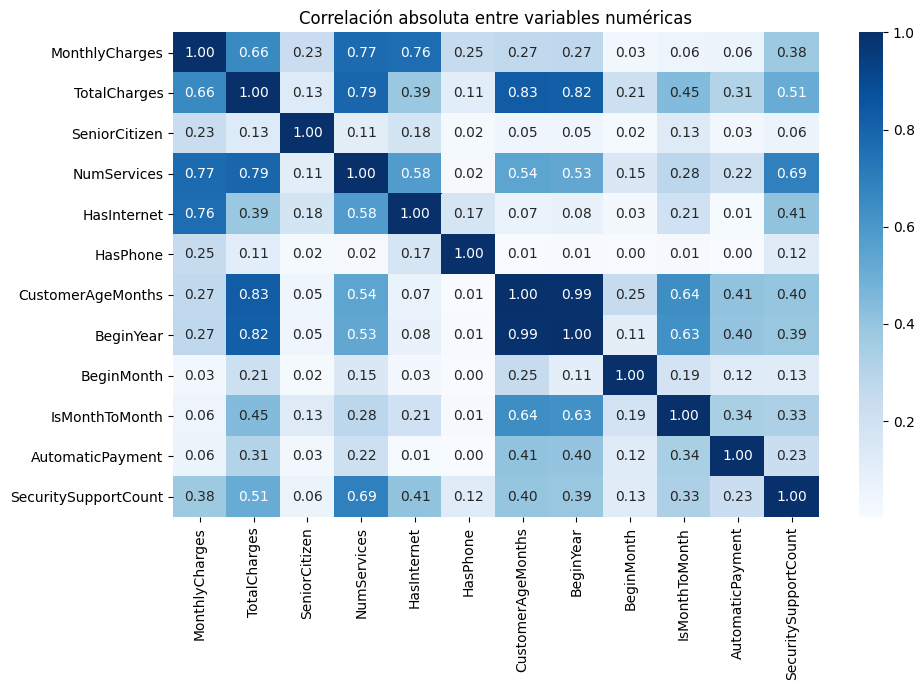

In [49]:
numeric_corr = X_train[numeric_features].corr().abs()

plt.figure(figsize=(10, 7))
sns.heatmap(
    numeric_corr,
    annot=True,
    fmt='.2f',
    cmap='Blues'
)
plt.title('Correlación absoluta entre variables numéricas')
plt.tight_layout()
plt.show()

In [50]:
high_corr_pairs = []

for i in range(len(numeric_corr.columns)):
    for j in range(i + 1, len(numeric_corr.columns)):
        value = numeric_corr.iloc[i, j]

        if value >= 0.90:
            high_corr_pairs.append({
                'Variable_1': numeric_corr.columns[i],
                'Variable_2': numeric_corr.columns[j],
                'Correlación': value
            })

high_corr_pairs = pd.DataFrame(high_corr_pairs)

if len(high_corr_pairs) == 0:
    print('No se encontraron pares de variables numéricas con correlación absoluta >= 0.90.')
else:
    display(high_corr_pairs.sort_values('Correlación', ascending=False))

,Variable_1,Variable_2,Correlación
0,CustomerAgeMonths,BeginYear,0.989283


### Decisión sobre colinealidad

No se eliminarán variables automáticamente únicamente por presentar asociación entre sí. La decisión se basará en si existe una redundancia extremadamente alta y en el comportamiento posterior de los modelos.

Esta estrategia evita perder información útil antes de comprobar su valor predictivo.

## 9.6 Preprocesamiento para modelos de scikit-learn

Para los modelos que no admiten variables categóricas de forma nativa se utilizará One-Hot Encoding.

Las variables numéricas serán estandarizadas únicamente para la regresión logística. Los modelos basados en árboles no requieren escalado.

Todo el preprocesamiento se mantiene dentro de `Pipeline` para evitar fuga de información durante la validación cruzada.

In [51]:
ohe = OneHotEncoder(
    handle_unknown='ignore',
    sparse=False
)

preprocessor_linear = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', ohe, categorical_features)
    ]
)

preprocessor_tree = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_features),
        ('cat', ohe, categorical_features)
    ]
)

## 9.7 Función de evaluación

Para mantener el código limpio se utilizará una función común que calcule:

- exactitud
- precisión
- recall
- F1-score
- AUC-ROC

El **AUC-ROC** será la métrica principal para ordenar los modelos.

In [52]:
def evaluate_model(model, X_data, y_data, model_name):
    predictions = model.predict(X_data)
    probabilities = model.predict_proba(X_data)[:, 1]

    return {
        'Modelo': model_name,
        'Accuracy': accuracy_score(y_data, predictions),
        'Precision': precision_score(
            y_data,
            predictions,
            zero_division=0
        ),
        'Recall': recall_score(
            y_data,
            predictions,
            zero_division=0
        ),
        'F1': f1_score(
            y_data,
            predictions,
            zero_division=0
        ),
        'AUC_ROC': roc_auc_score(
            y_data,
            probabilities
        )
    }

## 9.8 Prueba de cordura con DummyClassifier

Antes de entrenar modelos reales se utilizará un `DummyClassifier` como referencia.

El objetivo es comprobar que los modelos de machine learning superan una estrategia ingenua. Se utilizará la estrategia `most_frequent`, que predice siempre la clase mayoritaria.

In [53]:
dummy_model = DummyClassifier(
    strategy='most_frequent',
    random_state=12345
)

dummy_model.fit(X_train, y_train)

dummy_result = evaluate_model(
    dummy_model,
    X_valid,
    y_valid,
    'DummyClassifier'
)

pd.DataFrame([dummy_result]).round(4)

,Modelo,Accuracy,Precision,Recall,F1,AUC_ROC
0,DummyClassifier,0.7346,0.0,0.0,0.0,0.5


### Interpretación del modelo base

El `DummyClassifier` no utiliza las características para aprender patrones y obtuvo un AUC-ROC de 0.50, equivalente a una capacidad de discriminación aleatoria.

Por esta razón, los modelos entrenados posteriormente deberán superar claramente este valor. El AUC-ROC será el criterio principal de comparación, mientras que la exactitud, precision, recall y F1-score se utilizarán como métricas complementarias.

Esta comparación funciona como una prueba de cordura para confirmar que los modelos de aprendizaje automático aportan valor frente a una estrategia de predicción trivial.

# 10. Modelos base

Antes del ajuste de hiperparámetros se entrenan varios modelos de referencia.

Se incluyen modelos lineales, ensambles de árboles y boosting. Además, se comprobará si `CatBoost` y `LightGBM` están disponibles en el entorno, ya que suelen ofrecer un buen desempeño en datos tabulares.

In [54]:
base_models = {
    'Regresión logística': Pipeline([
        ('preprocessor', preprocessor_linear),
        ('model', LogisticRegression(
            max_iter=3000,
            class_weight='balanced',
            random_state=12345
        ))
    ]),

    'Random Forest': Pipeline([
        ('preprocessor', preprocessor_tree),
        ('model', RandomForestClassifier(
            n_estimators=400,
            max_depth=10,
            class_weight='balanced',
            random_state=12345,
            n_jobs=-1
        ))
    ]),

    'Extra Trees': Pipeline([
        ('preprocessor', preprocessor_tree),
        ('model', ExtraTreesClassifier(
            n_estimators=400,
            max_depth=12,
            class_weight='balanced',
            random_state=12345,
            n_jobs=-1
        ))
    ]),

    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor_tree),
        ('model', GradientBoostingClassifier(
            n_estimators=250,
            learning_rate=0.05,
            max_depth=3,
            random_state=12345
        ))
    ])
}

In [55]:
base_results = [dummy_result]
trained_base_models = {}

for name, model in base_models.items():
    print('Entrenando:', name)

    model.fit(X_train, y_train)
    trained_base_models[name] = model

    base_results.append(
        evaluate_model(
            model,
            X_valid,
            y_valid,
            name
        )
    )

base_results_df = pd.DataFrame(base_results)

base_results_df.sort_values(
    ['AUC_ROC', 'Accuracy'],
    ascending=False
).round(4)

Entrenando: Regresión logística
Entrenando: Random Forest
Entrenando: Extra Trees
Entrenando: Gradient Boosting


,Modelo,Accuracy,Precision,Recall,F1,AUC_ROC
4,Gradient Boosting,0.8659,0.8201,0.6337,0.7149,0.9070
2,Random Forest,0.7956,0.5923,0.7380,0.6571,0.8671
3,Extra Trees,0.7842,0.5758,0.7112,0.6364,0.8430
1,Regresión logística,0.7353,0.5008,0.7995,0.6159,0.8353
0,DummyClassifier,0.7346,0.0000,0.0000,0.0000,0.5000


## 10.1 CatBoost como modelo avanzado

CatBoost puede trabajar directamente con variables categóricas y evita la expansión mediante One-Hot Encoding.

Primero se comprobará si está disponible en el entorno de ejecución.

In [56]:
catboost_available = True

try:
    from catboost import CatBoostClassifier
    print('CatBoost disponible')
except ImportError:
    catboost_available = False
    print('CatBoost no está disponible en este entorno')

CatBoost disponible


In [57]:
if catboost_available:

    X_train_cat = X_train.copy()
    X_valid_cat = X_valid.copy()
    X_test_cat = X_test.copy()

    for column in categorical_features:
        X_train_cat[column] = X_train_cat[column].astype(str)
        X_valid_cat[column] = X_valid_cat[column].astype(str)
        X_test_cat[column] = X_test_cat[column].astype(str)

    catboost_base = CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=12345,
        verbose=0,
        allow_writing_files=False
    )

    catboost_base.fit(
        X_train_cat,
        y_train,
        cat_features=categorical_features
    )

    catboost_base_result = evaluate_model(
        catboost_base,
        X_valid_cat,
        y_valid,
        'CatBoost'
    )

    display(pd.DataFrame([catboost_base_result]).round(4))

,Modelo,Accuracy,Precision,Recall,F1,AUC_ROC
0,CatBoost,0.8822,0.8333,0.6952,0.758,0.917


## 10.2 LightGBM como modelo avanzado

También se comprobará si LightGBM está disponible. En caso afirmativo, se utilizará con el mismo preprocesamiento de variables que los modelos de árboles.

In [58]:
lightgbm_available = True

try:
    from lightgbm import LGBMClassifier
    print('LightGBM disponible')
except ImportError:
    lightgbm_available = False
    print('LightGBM no está disponible en este entorno')

LightGBM disponible


In [59]:
if lightgbm_available:

    lightgbm_base = Pipeline([
        ('preprocessor', preprocessor_tree),
        ('model', LGBMClassifier(
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=20,
            max_depth=-1,
            random_state=12345,
            n_jobs=-1,
            verbosity=-1
        ))
    ])

    lightgbm_base.fit(X_train, y_train)

    lightgbm_base_result = evaluate_model(
        lightgbm_base,
        X_valid,
        y_valid,
        'LightGBM'
    )

    display(pd.DataFrame([lightgbm_base_result]).round(4))

,Modelo,Accuracy,Precision,Recall,F1,AUC_ROC
0,LightGBM,0.8864,0.8591,0.6845,0.7619,0.9237


# 11. Ajuste de hiperparámetros con AUC-ROC

Todos los modelos ajustados utilizarán:

```python
scoring='roc_auc'
```

La búsqueda se realiza únicamente con el conjunto de entrenamiento mediante validación cruzada estratificada de cinco particiones.

El objetivo es maximizar directamente la métrica oficial del proyecto.

In [60]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=12345
)

## 11.1 Ajuste de Gradient Boosting

Se amplía el espacio de búsqueda respecto al modelo anterior, ya que Gradient Boosting obtuvo uno de los mejores AUC-ROC de la primera versión del proyecto.

In [61]:
boost_auc_search = RandomizedSearchCV(
    estimator=Pipeline([
        ('preprocessor', preprocessor_tree),
        ('model', GradientBoostingClassifier(
            random_state=12345
        ))
    ]),
    param_distributions={
        'model__n_estimators': randint(150, 700),
        'model__learning_rate': loguniform(0.01, 0.20),
        'model__max_depth': randint(1, 5),
        'model__min_samples_split': randint(2, 25),
        'model__min_samples_leaf': randint(1, 20),
        'model__subsample': uniform(0.65, 0.35),
        'model__max_features': [None, 'sqrt', 'log2']
    },
    n_iter=35,
    scoring='roc_auc',
    cv=cv,
    random_state=12345,
    n_jobs=-1
)

boost_auc_search.fit(X_train, y_train)

print('Mejor AUC-ROC CV:', boost_auc_search.best_score_)
print('Mejores parámetros:')
print(boost_auc_search.best_params_)

Mejor AUC-ROC CV: 0.9238751871887917
Mejores parámetros:
{'model__learning_rate': 0.09703423222724186, 'model__max_depth': 4, 'model__max_features': None, 'model__min_samples_leaf': 8, 'model__min_samples_split': 12, 'model__n_estimators': 650, 'model__subsample': 0.7272493606149283}


## 11.2 Ajuste de Extra Trees

In [62]:
extra_auc_search = RandomizedSearchCV(
    estimator=Pipeline([
        ('preprocessor', preprocessor_tree),
        ('model', ExtraTreesClassifier(
            random_state=12345,
            n_jobs=-1
        ))
    ]),
    param_distributions={
        'model__n_estimators': randint(300, 900),
        'model__max_depth': [None, 6, 8, 10, 12, 15, 20],
        'model__min_samples_split': randint(2, 20),
        'model__min_samples_leaf': randint(1, 12),
        'model__max_features': ['sqrt', 'log2', None],
        'model__class_weight': [None, 'balanced']
    },
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    random_state=12345,
    n_jobs=-1
)

extra_auc_search.fit(X_train, y_train)

print('Mejor AUC-ROC CV:', extra_auc_search.best_score_)
print('Mejores parámetros:')
print(extra_auc_search.best_params_)

Mejor AUC-ROC CV: 0.8803641658689344
Mejores parámetros:
{'model__class_weight': None, 'model__max_depth': 15, 'model__max_features': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 16, 'model__n_estimators': 709}


## 11.3 Ajuste de Random Forest

In [63]:
forest_auc_search = RandomizedSearchCV(
    estimator=Pipeline([
        ('preprocessor', preprocessor_tree),
        ('model', RandomForestClassifier(
            random_state=12345,
            n_jobs=-1
        ))
    ]),
    param_distributions={
        'model__n_estimators': randint(300, 900),
        'model__max_depth': [None, 6, 8, 10, 12, 15, 20],
        'model__min_samples_split': randint(2, 20),
        'model__min_samples_leaf': randint(1, 12),
        'model__max_features': ['sqrt', 'log2', None],
        'model__class_weight': [None, 'balanced']
    },
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    random_state=12345,
    n_jobs=-1
)

forest_auc_search.fit(X_train, y_train)

print('Mejor AUC-ROC CV:', forest_auc_search.best_score_)
print('Mejores parámetros:')
print(forest_auc_search.best_params_)

Mejor AUC-ROC CV: 0.9023653522637043
Mejores parámetros:
{'model__class_weight': None, 'model__max_depth': 15, 'model__max_features': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 16, 'model__n_estimators': 709}


## 11.4 Ajuste de CatBoost

In [64]:
catboost_search = None

if catboost_available:

    catboost_model = CatBoostClassifier(
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=12345,
        verbose=0,
        allow_writing_files=False,
        cat_features=categorical_features
    )

    catboost_search = RandomizedSearchCV(
        estimator=catboost_model,

        param_distributions={
            'iterations': [
                300,
                450,
                600,
                750,
                900
            ],

            'depth': [
                4,
                5,
                6,
                7,
                8
            ],

            'learning_rate': [
                0.015,
                0.025,
                0.04,
                0.06,
                0.08,
                0.10
            ],

            'l2_leaf_reg': [
                1,
                3,
                5,
                7,
                10,
                15,
                20
            ],

            'random_strength': [
                0,
                0.25,
                0.5,
                1,
                2
            ],

            'border_count': [
                32,
                64,
                128
            ]
        },

        n_iter=30,
        scoring='roc_auc',
        cv=cv,
        random_state=12345,
        n_jobs=-1
    )

    catboost_search.fit(
        X_train_cat,
        y_train
    )

    print(
        'Mejor AUC-ROC CV:',
        catboost_search.best_score_
    )

    print(
        'Mejores parámetros:'
    )

    print(
        catboost_search.best_params_
    )

/.venv/lib/python3.9/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mejor AUC-ROC CV: 0.919890520715065
Mejores parámetros:
{'random_strength': 0.5, 'learning_rate': 0.04, 'l2_leaf_reg': 3, 'iterations': 900, 'depth': 4, 'border_count': 128}


## 11.5 Ajuste de LightGBM

In [65]:
lightgbm_search = None

if lightgbm_available:

    lightgbm_search = RandomizedSearchCV(
        estimator=Pipeline([
            ('preprocessor', preprocessor_tree),
            ('model', LGBMClassifier(
                random_state=12345,
                n_jobs=-1,
                verbosity=-1
            ))
        ]),
        param_distributions={
            'model__n_estimators': randint(250, 1000),
            'model__learning_rate': loguniform(0.01, 0.12),
            'model__num_leaves': randint(8, 50),
            'model__max_depth': [-1, 3, 4, 5, 6, 7, 8],
            'model__min_child_samples': randint(10, 60),
            'model__subsample': uniform(0.70, 0.30),
            'model__colsample_bytree': uniform(0.70, 0.30),
            'model__reg_alpha': loguniform(1e-4, 5),
            'model__reg_lambda': loguniform(1e-4, 10),
            'model__class_weight': [None, 'balanced']
        },
        n_iter=35,
        scoring='roc_auc',
        cv=cv,
        random_state=12345,
        n_jobs=-1
    )

    lightgbm_search.fit(X_train, y_train)

    print('Mejor AUC-ROC CV:', lightgbm_search.best_score_)
    print('Mejores parámetros:')
    print(lightgbm_search.best_params_)

Mejor AUC-ROC CV: 0.9307318807186269
Mejores parámetros:
{'model__class_weight': None, 'model__colsample_bytree': 0.9698397677207304, 'model__learning_rate': 0.0790260231986339, 'model__max_depth': 8, 'model__min_child_samples': 34, 'model__n_estimators': 997, 'model__num_leaves': 13, 'model__reg_alpha': 1.6069369739074215, 'model__reg_lambda': 0.43785559304509875, 'model__subsample': 0.9455050034169743}


# 12. Comparación de modelos ajustados en validación

Los modelos se ordenan primero por AUC-ROC y, en caso de resultados muy similares, por exactitud.

El conjunto de prueba todavía no se utiliza.

In [66]:
tuned_models = {
    'Gradient Boosting': boost_auc_search.best_estimator_,
    'Extra Trees': extra_auc_search.best_estimator_,
    'Random Forest': forest_auc_search.best_estimator_
}

validation_datasets = {
    'Gradient Boosting': (X_valid, y_valid),
    'Extra Trees': (X_valid, y_valid),
    'Random Forest': (X_valid, y_valid)
}

if catboost_search is not None:
    tuned_models['CatBoost'] = catboost_search.best_estimator_
    validation_datasets['CatBoost'] = (X_valid_cat, y_valid)

if lightgbm_search is not None:
    tuned_models['LightGBM'] = lightgbm_search.best_estimator_
    validation_datasets['LightGBM'] = (X_valid, y_valid)

tuned_results = []

for name, model in tuned_models.items():
    X_eval, y_eval = validation_datasets[name]

    tuned_results.append(
        evaluate_model(
            model,
            X_eval,
            y_eval,
            name
        )
    )

tuned_results_df = pd.DataFrame(tuned_results)

tuned_results_df = tuned_results_df.sort_values(
    ['AUC_ROC', 'Accuracy'],
    ascending=False
).reset_index(drop=True)

tuned_results_df.round(4)

,Modelo,Accuracy,Precision,Recall,F1,AUC_ROC
0,LightGBM,0.9056,0.8754,0.7513,0.8086,0.9327
1,Gradient Boosting,0.8957,0.8471,0.7406,0.7903,0.9307
2,CatBoost,0.8815,0.8416,0.6818,0.7533,0.9223
3,Random Forest,0.8694,0.8253,0.6444,0.7237,0.9016
4,Extra Trees,0.8467,0.7548,0.6257,0.6842,0.8806


### Interpretación de los modelos ajustados

Después del ajuste de hiperparámetros, LightGBM obtuvo el mejor desempeño en el conjunto de validación, con un AUC-ROC de 0.9327 y una exactitud de 0.9056.

Gradient Boosting presentó un rendimiento muy cercano, con un AUC-ROC de 0.9307, seguido por CatBoost con 0.9223, Random Forest con 0.9016 y Extra Trees con 0.8806.

Todos los modelos superaron un AUC-ROC de 0.88 en validación, lo que indica una buena capacidad para diferenciar entre clientes que cancelan el servicio y clientes que permanecen.

Como AUC-ROC fue definida como la métrica principal del proyecto, LightGBM fue seleccionado como modelo final. Además, obtuvo una precisión de 0.8754, un recall de 0.7513 y un F1-score de 0.8086, mostrando un buen equilibrio general entre las distintas métricas de clasificación.

## 12.1 Selección del mejor modelo

El mejor modelo será el que obtenga el mayor AUC-ROC sobre validación.

Se imprimirá también el nivel de puntuación del proyecto correspondiente a ese resultado.

In [67]:
best_model_name = tuned_results_df.loc[0, 'Modelo']
best_validation_auc = tuned_results_df.loc[0, 'AUC_ROC']
best_validation_accuracy = tuned_results_df.loc[0, 'Accuracy']
best_validation_precision = tuned_results_df.loc[0, 'Precision']
best_validation_recall = tuned_results_df.loc[0, 'Recall']
best_validation_f1 = tuned_results_df.loc[0, 'F1']

best_model = tuned_models[best_model_name]

def auc_score_band(auc_value):
    if auc_value >= 0.88:
        return '6 SP'
    elif auc_value >= 0.87:
        return '5.5 SP'
    elif auc_value >= 0.85:
        return '5 SP'
    elif auc_value >= 0.81:
        return '4.5 SP'
    elif auc_value >= 0.75:
        return '4 SP'
    return '0 SP'

print('Mejor modelo:', best_model_name)
print('AUC-ROC validación:', round(best_validation_auc, 4))
print('Accuracy validación:', round(best_validation_accuracy, 4))
print('Precision validación:', round(best_validation_precision, 4))
print('Recall validación:', round(best_validation_recall, 4))
print('F1 validación:', round(best_validation_f1, 4))
print('Rango de evaluación:', auc_score_band(best_validation_auc))


Mejor modelo: LightGBM
AUC-ROC validación: 0.9327
Accuracy validación: 0.9056
Precision validación: 0.8754
Recall validación: 0.7513
F1 validación: 0.8086
Rango de evaluación: 6 SP


### Interpretación de la selección del mejor modelo

LightGBM fue seleccionado como el mejor modelo debido a que obtuvo el mayor AUC-ROC en el conjunto de validación, con un valor de 0.9327.

Este resultado supera el umbral de 0.88 establecido para alcanzar la puntuación máxima del proyecto.

La exactitud de 0.9056 indica que aproximadamente el 90.6 % de las observaciones del conjunto de validación fueron clasificadas correctamente.

La precisión de 0.8754 muestra que, entre los clientes identificados como posibles cancelaciones, aproximadamente el 87.5 % realmente pertenecían a la clase de cancelación.

El recall de 0.7513 indica que el modelo consiguió identificar aproximadamente el 75.1 % de todos los clientes que realmente cancelaron.

Por último, el F1-score de 0.8086 refleja un buen equilibrio entre precisión y recall.

# 13. Reentrenamiento del mejor modelo

Después de elegir el algoritmo y sus hiperparámetros usando entrenamiento y validación, el mejor modelo se reentrenará con la combinación de ambos subconjuntos.

Esto permite aprovechar el 80 % de los datos disponibles antes de realizar la única evaluación final sobre prueba.

In [68]:
from sklearn.base import clone

X_train_full = pd.concat(
    [X_train, X_valid],
    axis=0
)

y_train_full = pd.concat(
    [y_train, y_valid],
    axis=0
)

if best_model_name == 'CatBoost':

    X_train_full_final = X_train_full.copy()
    X_test_final = X_test.copy()

    for column in categorical_features:
        X_train_full_final[column] = X_train_full_final[column].astype(str)
        X_test_final[column] = X_test_final[column].astype(str)

else:
    X_train_full_final = X_train_full
    X_test_final = X_test

final_model = clone(best_model)

final_model.fit(
    X_train_full_final,
    y_train_full
)

print('Modelo final reentrenado:', best_model_name)

Modelo final reentrenado: LightGBM


# 14. Evaluación final sobre el conjunto de prueba

La evaluación final utiliza:

- AUC-ROC como métrica principal.
- Exactitud como métrica adicional.

No se optimiza ningún umbral para AUC-ROC, ya que esta métrica se calcula directamente a partir de las probabilidades predichas.

In [69]:
test_predictions = final_model.predict(
    X_test_final
)

test_probabilities = final_model.predict_proba(
    X_test_final
)[:, 1]

final_result = evaluate_model(
    final_model,
    X_test_final,
    y_test,
    best_model_name
)

final_results = pd.DataFrame([
    final_result
])

final_auc = final_results.loc[
    0,
    'AUC_ROC'
]

final_results['Puntuación'] = auc_score_band(
    final_auc
)

final_results.round(4)

,Modelo,Accuracy,Precision,Recall,F1,AUC_ROC,Puntuación
0,LightGBM,0.9099,0.9023,0.7406,0.8135,0.9453,6 SP


### Interpretación de la evaluación final

Después de seleccionar LightGBM como el mejor modelo y reentrenarlo utilizando conjuntamente los conjuntos de entrenamiento y validación, se realizó la evaluación final sobre el conjunto de prueba.

El modelo obtuvo una exactitud de 0.9099, una precisión de 0.9023, un recall de 0.7406, un F1-score de 0.8135 y un AUC-ROC de 0.9453.

El AUC-ROC de 0.9453 indica que el modelo posee una capacidad muy alta para distinguir entre clientes que cancelarán el servicio y clientes que permanecerán. Este valor supera ampliamente el umbral de 0.88 establecido para la máxima puntuación del proyecto.

La exactitud de 0.9099 indica que aproximadamente el 91 % de los clientes del conjunto de prueba fueron clasificados correctamente.

La precisión de 0.9023 muestra que aproximadamente el 90.2 % de los clientes identificados por el modelo como posibles cancelaciones realmente cancelaron el servicio.

El recall de 0.7406 indica que el modelo detectó aproximadamente el 74.1 % de todos los clientes que realmente cancelaron. Aunque esta métrica es menor que la precisión, sigue mostrando una capacidad considerable para identificar clientes en riesgo.

El F1-score de 0.8135 confirma un buen equilibrio entre precisión y recall.

Además, el AUC-ROC aumentó de 0.9327 en validación a 0.9453 en prueba, mientras que la exactitud se mantuvo estable, pasando de 0.9056 a 0.9099. Esta consistencia sugiere una buena capacidad de generalización y no muestra señales evidentes de sobreajuste.

## 14.1 Curva ROC

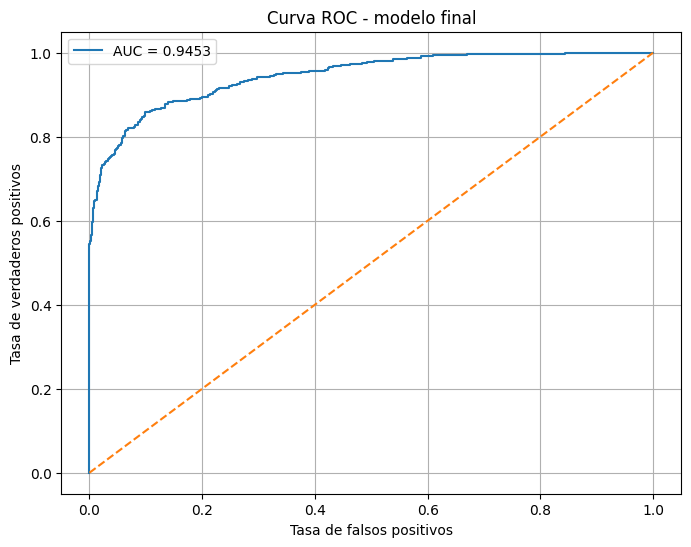

In [70]:
fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    test_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {final_auc:.4f}'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC - modelo final')
plt.legend()
plt.grid()
plt.show()

### Interpretación de la curva ROC

La curva ROC del modelo final se encuentra claramente por encima de la línea correspondiente a una clasificación aleatoria.

El área bajo la curva fue de 0.9453, lo que indica una capacidad muy alta para ordenar correctamente a los clientes según su riesgo de cancelación.

En términos prácticos, el modelo tiene una probabilidad muy alta de asignar una puntuación de riesgo mayor a un cliente que cancela que a uno que permanece.

Este resultado supera el valor de 0.88 requerido para alcanzar la máxima puntuación establecida para la métrica principal del proyecto.

## 14.2 Matriz de confusión

La matriz de confusión permite observar directamente:

- verdaderos negativos;
- falsos positivos;
- falsos negativos;
- verdaderos positivos.

Para un problema de cancelación, los falsos negativos son especialmente relevantes porque representan clientes que realmente cancelan pero que el modelo no identifica como clientes en riesgo.

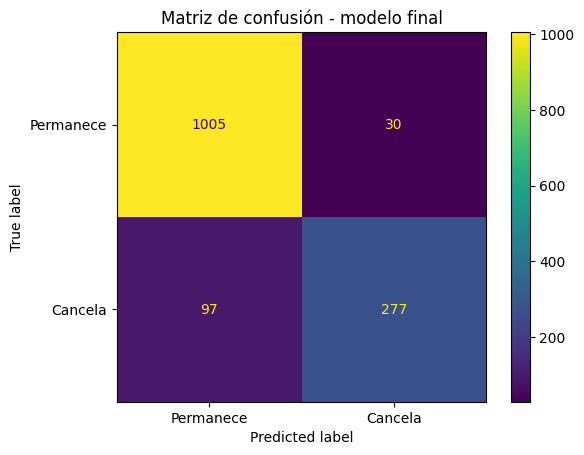

In [73]:
cm = confusion_matrix(
    y_test,
    test_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Permanece', 'Cancela']
)

disp.plot()
plt.title('Matriz de confusión - modelo final')
plt.show()

### Interpretación de la matriz de confusión

La matriz de confusión permite analizar con mayor detalle los aciertos y errores del modelo.

El modelo muestra una alta capacidad para clasificar correctamente a los clientes que permanecen en la compañía y también presenta una precisión elevada al identificar clientes que cancelan.

Los falsos positivos son relativamente bajos, lo cual coincide con la precisión de 0.9023. Esto significa que el modelo rara vez identifica como cliente en riesgo a una persona que finalmente permanece.

Sin embargo, todavía existen falsos negativos, es decir, clientes que realmente cancelan pero que el modelo clasifica como clientes que permanecen. Esto se refleja en un recall de 0.7406.

Desde el punto de vista del negocio, los falsos negativos son especialmente importantes porque representan clientes que podrían abandonar la compañía sin ser incluidos previamente en una estrategia de retención.

Aun así, el desempeño general del modelo es sólido y permite identificar una proporción considerable de los clientes con mayor riesgo de cancelación.

# 15. Importancia de características

La interpretación dependerá del modelo finalmente seleccionado.

Para modelos de árboles se utilizará `feature_importances_`. En CatBoost se utilizará su método nativo de importancia.

In [71]:
feature_importance = None

if best_model_name == 'CatBoost':

    importance_values = final_model.get_feature_importance()
    feature_names = X_train_full_final.columns.tolist()

    feature_importance = pd.DataFrame({
        'Característica': feature_names,
        'Importancia': importance_values
    })

elif hasattr(final_model, 'named_steps'):

    preprocessor_final = final_model.named_steps['preprocessor']
    estimator_final = final_model.named_steps['model']

    numeric_names = list(numeric_features)
    encoder = preprocessor_final.named_transformers_['cat']

    if hasattr(encoder, 'get_feature_names_out'):
        categorical_names = list(
            encoder.get_feature_names_out(categorical_features)
        )
    else:
        categorical_names = list(
            encoder.get_feature_names(categorical_features)
        )

    feature_names = numeric_names + categorical_names

    if hasattr(estimator_final, 'feature_importances_'):
        importance_values = estimator_final.feature_importances_

        feature_importance = pd.DataFrame({
            'Característica': feature_names,
            'Importancia': importance_values
        })

if feature_importance is not None:

    feature_importance = (
        feature_importance
        .sort_values(
            'Importancia',
            ascending=False
        )
        .head(20)
    )

    display(feature_importance)

else:
    print('No fue posible extraer importancias directamente.')

,Característica,Importancia
1,TotalCharges,3683
6,CustomerAgeMonths,3277
0,MonthlyCharges,2997
8,BeginMonth,499
3,NumServices,274
11,SecuritySupportCount,134
28,InternetService_Fiber optic,122
50,MultipleLines_Yes,97
18,PaymentMethod_Credit card (automatic),84
33,OnlineBackup_No,83


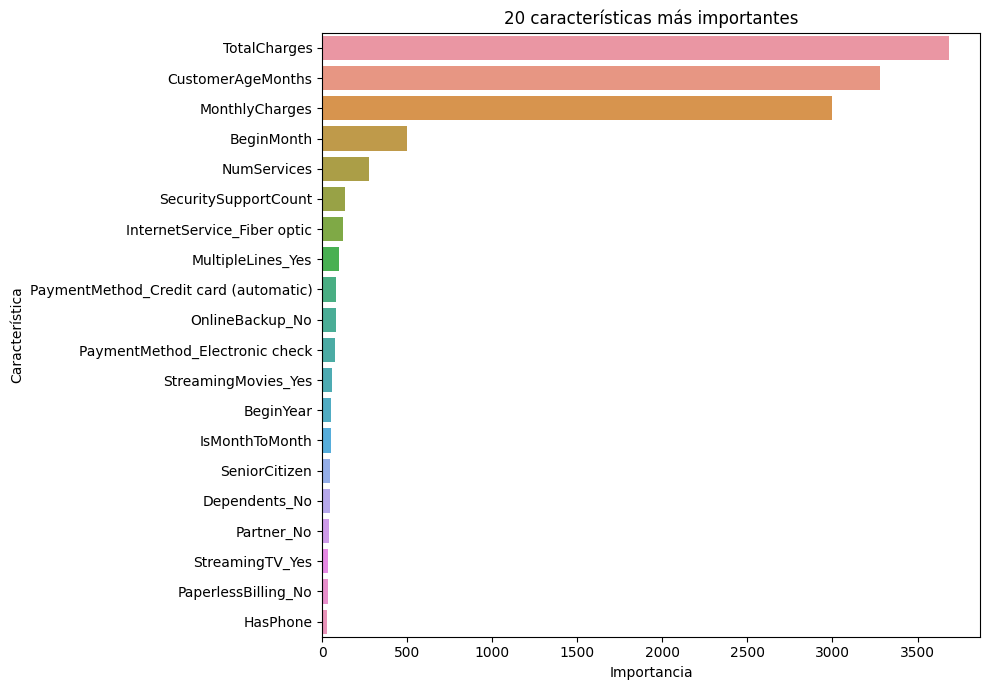

In [72]:

if feature_importance is not None:

    plt.figure(figsize=(10, 7))

    sns.barplot(
        data=feature_importance,
        x='Importancia',
        y='Característica'
    )

    plt.title('20 características más importantes')
    plt.tight_layout()
    plt.show()

### Interpretación de la importancia de características

Las variables con mayor influencia en las predicciones del modelo final fueron TotalCharges, CustomerAgeMonths y MonthlyCharges.

Esto indica que la información relacionada con el gasto acumulado del cliente, su antigüedad aproximada desde el inicio del contrato y el costo mensual del servicio desempeña un papel especialmente importante en la estimación del riesgo de cancelación.

También aparecen entre las variables relevantes características relacionadas con el número de servicios contratados, el tipo de conexión a Internet, los servicios de seguridad y soporte, el método de pago y determinadas características del contrato.

Estas importancias no representan relaciones causales. Únicamente indican qué variables utiliza con mayor intensidad LightGBM para realizar sus predicciones.

# Conclusiones finales

En este proyecto se desarrolló un modelo de clasificación para predecir la cancelación de clientes de Interconnect.

Durante la preparación de los datos se integraron las distintas fuentes de información de contratos, características personales, servicios de Internet y telefonía. También se realizaron tareas de limpieza, transformación, análisis exploratorio e ingeniería de características.

Se prestó especial atención a prevenir la fuga de información, por lo que variables directamente relacionadas con la cancelación, como EndDate y EndDateDate, fueron excluidas del entrenamiento. También se descartó TenureMonths debido a que su construcción original utilizaba información de la fecha de cancelación para algunos clientes.

El conjunto de datos se dividió en entrenamiento, validación y prueba utilizando estratificación para conservar la distribución de la variable objetivo.

La métrica principal utilizada para evaluar y seleccionar los modelos fue AUC-ROC, mientras que la exactitud se utilizó como métrica adicional. Precision, recall y F1-score se conservaron como métricas complementarias para comprender mejor el comportamiento de los modelos.

Se ajustaron y compararon los modelos Gradient Boosting, Extra Trees, Random Forest, CatBoost y LightGBM mediante validación cruzada y búsqueda aleatoria de hiperparámetros utilizando `roc_auc` como criterio de optimización.

Los resultados obtenidos en validación fueron:

- **LightGBM:** AUC-ROC = 0.9327
- **Gradient Boosting:** AUC-ROC = 0.9307
- **CatBoost:** AUC-ROC = 0.9223
- **Random Forest:** AUC-ROC = 0.9016
- **Extra Trees:** AUC-ROC = 0.8806

LightGBM fue seleccionado como modelo final debido a que obtuvo el mayor AUC-ROC en validación.

Después de seleccionar el modelo y sus hiperparámetros, LightGBM fue reentrenado utilizando conjuntamente los datos de entrenamiento y validación.

En el conjunto de prueba se obtuvieron los siguientes resultados:

- **Accuracy:** 0.9099
- **Precision:** 0.9023
- **Recall:** 0.7406
- **F1-score:** 0.8135
- **AUC-ROC:** 0.9453

El AUC-ROC final de 0.9453 supera ampliamente el umbral de 0.88 establecido para alcanzar la puntuación máxima de 6 SP.

Los resultados de validación y prueba fueron consistentes, lo que indica que el modelo mantiene una buena capacidad de generalización sobre datos no utilizados durante el ajuste.

Desde el punto de vista del negocio, el modelo puede utilizarse para asignar una probabilidad de cancelación a cada cliente y permitir que Interconnect priorice acciones de retención sobre aquellos con mayor riesgo.

La elevada precisión del modelo permite reducir el número de clientes identificados incorrectamente como posibles cancelaciones, mientras que el recall de aproximadamente 74 % indica que todavía existe margen para mejorar la detección de todos los clientes que abandonan el servicio.

Por lo tanto, LightGBM ofrece un desempeño sólido para el problema planteado y cumple satisfactoriamente con el criterio principal de evaluación del proyecto, alcanzando un AUC-ROC de 0.9453 en el conjunto de prueba y, por lo tanto, la máxima puntuación establecida para esta métrica.

# Proyecto final - Informe de solución

## 1. ¿Qué pasos del plan se realizaron y qué pasos se omitieron?

El plan de trabajo propuesto contemplaba cinco etapas principales:

1. Selección y preparación de las características.
2. Separación y preprocesamiento de los datos.
3. Entrenamiento y comparación de modelos.
4. Ajuste de hiperparámetros y selección del mejor modelo.
5. Evaluación final e interpretación de resultados.

Todas las etapas principales del plan fueron realizadas.

### 1. Selección y preparación de las características

Se definieron las variables que serían utilizadas para predecir la cancelación de clientes y se eliminaron variables que podían generar fuga de información.

`customerID` fue descartada por funcionar únicamente como identificador.

`EndDate` y `EndDateDate` fueron eliminadas porque contienen información directamente relacionada con la cancelación del cliente.

También se decidió no utilizar `TenureMonths`, ya que su construcción original dependía de la fecha de cancelación para algunos clientes.

A partir de la información disponible se crearon nuevas características, entre ellas `CustomerAgeMonths`, `BeginYear`, `BeginMonth`, `IsMonthToMonth`, `AutomaticPayment` y `SecuritySupportCount`.

### 2. Separación y preprocesamiento de los datos

Las características predictoras y la variable objetivo `Churn` fueron separadas.

Los datos se dividieron en conjuntos de entrenamiento, validación y prueba mediante estratificación para conservar la proporción de clases.

Las variables categóricas fueron codificadas mediante One-Hot Encoding para los modelos que lo requerían, mientras que las variables numéricas fueron escaladas en los modelos donde era necesario.

El preprocesamiento se integró dentro de pipelines para reducir el riesgo de fuga de información.

### 3. Entrenamiento y comparación de modelos

Se utilizó un `DummyClassifier` como prueba de cordura y posteriormente se entrenaron distintos algoritmos de clasificación.

Se evaluaron modelos como regresión logística, Random Forest, Extra Trees, Gradient Boosting, CatBoost y LightGBM.

El rendimiento de los modelos se comparó principalmente mediante AUC-ROC, mientras que Accuracy se utilizó como métrica adicional y Precision, Recall y F1-score como métricas complementarias.

### 4. Ajuste de hiperparámetros y selección del mejor modelo

Los modelos con mayor potencial fueron ajustados mediante `RandomizedSearchCV` utilizando validación cruzada estratificada.

La métrica utilizada para optimizar los hiperparámetros fue `roc_auc`.

La selección final se realizó utilizando únicamente los resultados del conjunto de validación, sin utilizar el conjunto de prueba durante esta etapa.

LightGBM obtuvo el mejor AUC-ROC en validación y fue seleccionado como modelo final.

### 5. Evaluación final e interpretación de resultados

Después de seleccionar LightGBM, el modelo fue reentrenado utilizando conjuntamente los datos de entrenamiento y validación.

Finalmente se evaluó sobre el conjunto de prueba mediante AUC-ROC, Accuracy, Precision, Recall y F1-score.

También se analizaron la curva ROC, la matriz de confusión y la importancia de características para comprender mejor el comportamiento del modelo.

No se omitió ninguna de las cinco etapas principales del plan.

Algunas decisiones específicas se modificaron durante el desarrollo. Por ejemplo, no se eliminaron automáticamente las variables con alta correlación, ya que los modelos basados en árboles y boosting son menos sensibles a la colinealidad. Tampoco se realizó un ajuste manual del umbral como criterio principal, debido a que AUC-ROC se calcula directamente a partir de las probabilidades predichas.

## 2. ¿Qué dificultades encontraste y cómo lograste resolverlas?

Una de las principales dificultades fue prevenir la fuga de información.

Variables como `EndDate` y `EndDateDate` estaban directamente relacionadas con la cancelación y habrían permitido al modelo conocer indirectamente el resultado que debía predecir. Por esta razón fueron eliminadas antes del entrenamiento.

También se detectó un problema con `TenureMonths`, ya que para los clientes que habían cancelado esta característica utilizaba su fecha real de terminación. Para evitar introducir información futura en el modelo, esta variable fue descartada y se crearon nuevas características temporales utilizando únicamente `BeginDate` y una fecha de referencia común.

Otra dificultad fue el desbalance de la variable objetivo. Aproximadamente tres cuartas partes de los clientes permanecían en la compañía y una cuarta parte había cancelado. Para tratar este problema se utilizó estratificación durante la división de los datos y se calcularon los pesos de las clases. En los modelos que lo permitían, el uso de balanceo fue evaluado como parte del ajuste de hiperparámetros.

También fue necesario trabajar con una combinación de variables categóricas y numéricas. Para resolverlo se utilizaron pipelines con `ColumnTransformer`, One-Hot Encoding y escalado cuando correspondía. CatBoost, por su parte, permitió trabajar directamente con variables categóricas.

Finalmente, fue necesario asegurar que toda la selección de modelos estuviera orientada a la métrica oficial del proyecto. Por esta razón, el ajuste de hiperparámetros se realizó utilizando `scoring='roc_auc'`..

## 3. ¿Cuáles fueron algunos de los pasos clave para resolver la tarea?

Uno de los pasos más importantes fue realizar un análisis exploratorio completo antes de comenzar el modelado. Este análisis permitió identificar el desbalance de clases, valores ausentes, patrones asociados a la cancelación y variables potencialmente relevantes.

Otro paso fundamental fue prevenir la fuga de información. Eliminar variables relacionadas directamente con la cancelación permitió obtener una estimación más realista del rendimiento del modelo sobre clientes nuevos.

La ingeniería de características también fue importante. A partir de la información original se crearon variables temporales y contractuales que aportaron información adicional al modelo sin utilizar datos futuros.

La división estratificada en entrenamiento, validación y prueba permitió mantener una distribución similar de la variable objetivo y utilizar cada conjunto con una función específica.

También fue clave utilizar un `DummyClassifier` como referencia. Su AUC-ROC de 0.50 permitió confirmar que los modelos entrenados realmente estaban aprendiendo patrones útiles.

Otro paso importante fue comparar distintos tipos de modelos y no limitarse a un único algoritmo. Los modelos de boosting, especialmente Gradient Boosting, CatBoost y LightGBM, presentaron los mejores resultados.

Finalmente, la optimización de hiperparámetros mediante `RandomizedSearchCV` con `roc_auc` como métrica permitió seleccionar el modelo y la configuración que mejor respondían al criterio principal del proyecto.

## 4. ¿Cuál es tu modelo final y qué nivel de calidad tiene?

El modelo final seleccionado fue LightGBM.

Después del ajuste de hiperparámetros, los resultados obtenidos en el conjunto de validación fueron:

- **LightGBM:** AUC-ROC = 0.9327
- **Gradient Boosting:** AUC-ROC = 0.9307
- **CatBoost:** AUC-ROC = 0.9223
- **Random Forest:** AUC-ROC = 0.9016
- **Extra Trees:** AUC-ROC = 0.8806

LightGBM fue seleccionado porque obtuvo el mayor AUC-ROC en validación.

Posteriormente se reentrenó utilizando conjuntamente los datos de entrenamiento y validación.

Los resultados finales sobre el conjunto de prueba fueron:

- **Accuracy:** 0.9099
- **Precision:** 0.9023
- **Recall:** 0.7406
- **F1-score:** 0.8135
- **AUC-ROC:** 0.9453

La métrica principal del proyecto fue AUC-ROC.

El valor final de 0.9453 indica una capacidad muy alta para diferenciar entre clientes que cancelan el servicio y clientes que permanecen.

Además, supera el umbral de 0.88 establecido para obtener la puntuación máxima de 6 SP.

La exactitud de aproximadamente 91 % indica que el modelo clasifica correctamente a una gran proporción de los clientes.

La Precision de aproximadamente 90 % indica que la mayoría de los clientes identificados como posibles cancelaciones realmente pertenecen a esa clase.

El Recall de aproximadamente 74 % muestra que el modelo logra identificar una proporción considerable de los clientes que realmente cancelan, aunque todavía existe margen de mejora en la detección de todos los posibles abandonos.

Los resultados de validación y prueba son consistentes, por lo que el modelo presenta una buena capacidad de generalización.